In [1]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
import pickle

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


import numpy as np
import h5py
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Key emission lines for reference (rest-frame wavelengths in Angstroms)
emission_lines = {
    r"[OII] $\lambda$3727": 3727.0,
    r"H$\beta$": 4861.0,
    r"[OIII] $\lambda$4959": 4959.0,
    r"[OIII] $\lambda$5007": 5007.0,
    r"H$\alpha$": 6563.0,
    r"[NII] $\lambda$6584": 6584.0,
    r"[SII] $\lambda$6717": 6717.0,
    r"[SII] $\lambda$6731": 6731.0,
}

from elg_explore import load_catalog, load_spectra, select_sample, get_sample_spectra_with_linenorm,  normalize_by_line_catalog, bootstrap_stack

%load_ext autoreload
%autoreload 2


In [2]:
# from elg_explore import deredshift_for_stacking
# deredshift_for_stacking()

In [45]:

# Load data
print("\n[1] Loading catalog...")
tot_cat = load_catalog()
print(f"    Total galaxies after masking: {len(tot_cat)}")

print("\n[2] Loading spectra...")
spectra_data = load_spectra()
print(f"    Total spectra loaded: {len(spectra_data['targetid'])}")

wave = spectra_data["wave_rest"]
print(f"    Wavelength range: {wave.min():.1f} - {wave.max():.1f} Angstroms")

print(np.diff(wave)[:5])



[1] Loading catalog...
Total catalog size = 368807


Cleaned catalog size = 328094
    Total galaxies after masking: 328094

[2] Loading spectra...
Reading file = /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/desi_y1_dwarf_combine_deredshift_hires.h5
    Total spectra loaded: 368807
    Wavelength range: 3600.0 - 9819.6 Angstroms
[0.39990234 0.40014648 0.39990234 0.40014648 0.39990234]


In [46]:
mask = spectra_data['wave_rest'] < 6800

spectra_data['wave_rest'] = spectra_data['wave_rest'][mask]
spectra_data['flux'] = spectra_data['flux'][:, mask]
spectra_data['flux_ivar'] = spectra_data['flux_ivar'][:, mask]

In [47]:
spectra_data["flux"].shape

(368807, 8000)

In [48]:
wave = spectra_data["wave_rest"]
print(f"    Wavelength range: {wave.min():.1f} - {wave.max():.1f} Angstroms")

print(np.diff(wave)[:5])


    Wavelength range: 3600.0 - 6799.6 Angstroms
[0.39990234 0.40014648 0.39990234 0.40014648 0.39990234]


In [53]:
# #read the entire consolidated file!
# with h5py.File("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5", "r") as f:
#     wave_org = f["WAVE"][:]
#     flux_org = f["FLUX"][:] 
#     flux_ivar_org = f["FLUX_IVAR"][:] 
#     zreds_org = f["Z"][:]  
#     tgids_org = f["TARGETID"][:] 
    
# print("wave shape", wave_org.shape)
# print("flux shape", flux_org.shape)
# print("flux_ivar shape", flux_ivar_org.shape)
# print("zreds shape", zreds_org.shape)

In [140]:

shorten = -1
cont_width=10
LINE_WINDOWS = {
    "Halpha": (6558.0 - shorten, 6571.0 + shorten,5),
    "NII_6548": (6545.0 + 1, 6555.0 - 1, 5),
    "NII_6583": (6578.0 + 2, 6592.0 - 2,cont_width),
    "Hbeta": (4848.0 + 10, 4878.0 - 10, 3),
    "OIII_4959": (4945.0 + 10, 4975.0 - 10,5),
    "OIII_5007": (4990.0 + 10, 5025.0 - 10,5),
    "OII": (3710.0 + 12, 3750.0 - 14,5),
    "SII": (6700.0 + 12, 6755.0 - 16 , 5),
}

zred_bins = np.concatenate( [ np.arange(0.01, 0.15, 0.01) , np.arange(0.15, 0.35,0.05) ] )

zcens = 0.5 * (zred_bins[1:] + zred_bins[:-1])

from elg_explore import measure_all_lines_boxcar, compute_line_ratios_bootstrap, bootstrap_stack


In [141]:
zred_bins

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.2 , 0.25, 0.3 ])

## TESTING PART

In [56]:
# =============================================================================
# Main loop
# =============================================================================

stack_spec_elg_dict = {}
stack_spec_noelg_dict = {}
line_ratios_elg_dict = {}
line_ratios_noelg_dict = {}

stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/"

# Create directory if it doesn't exist
os.makedirs(stack_path, exist_ok=True)

i = 4

zmin_i = zred_bins[i]
zmax_i = zred_bins[i + 1]

elg_sub_cat_i = select_sample(tot_cat, "ELG", z_min=zmin_i, z_max=zmax_i)

# ----------------------------
# ELG stack
# ----------------------------
print(f"Computing ELG stack for z=[{zmin_i:.3f}, {zmax_i:.3f}]")


flux_elg_i, ivar_elg_i, haf_elg_i, tgids_elg_i = get_sample_spectra_with_linenorm(
    elg_sub_cat_i, spectra_data, line_norm="HALPHA"
)

stack_spec_elg, stack_err_elg, all_stacks_elg = bootstrap_stack(
    fluxes = flux_elg_i, 
    ivars = ivar_elg_i, 
    wave = wave,
    norm_method = "catalog",
    catalog_line_fluxes = haf_elg_i)

# Save the stacked spectra
save_data = {
    'stack_spec': stack_spec_elg,
    'stack_err': stack_err_elg,
    'all_stacks': all_stacks_elg,
    'zmin': zmin_i,
    'zmax': zmax_i,
    'n_galaxies': len(elg_sub_cat_i)
}

# Compute line ratios directly from bootstrap realizations
line_ratios_elg_dict_i = compute_line_ratios_bootstrap(
    wave, all_stacks_elg, LINE_WINDOWS
)


Total number selected = 1273
Computing ELG stack for z=[0.050, 0.060]
NDRAW = 5000
    Catalog normalization: 1273/1273 spectra with valid line flux


## Doing test of line flux measurement and de-redshifting and stacking!
We will measure the Halpha flux on de-redshifted spectra and original spectra and compare!
Ideally they are the same ...

In [8]:
from desispec.interpolation import resample_flux


In [146]:

def _deredshift_one_spectrum(wave, flux, ivar, zred, wave_out=np.arange(3600,9820,0.4)):
    
    rest_wave = wave / (1 + zred)
    flux_rest = flux * (1 + zred)
    ivar_rest = ivar / (1 + zred)**2

    flux_out = resample_flux(wave_out, rest_wave, flux_rest, ivar=None)

    _, ivar_out = resample_flux(wave_out, rest_wave, flux_rest, ivar=ivar_rest)
    
    return wave_out, flux_out, ivar_out


halpha_org_spec = []
halpha_dered_spec = []
halpha_dered_new_spec = []

flux_out_new = []
flux_ivar_out_new = []

for spec_ind in trange(len(elg_sub_cat_i)):
    ###measure line flux on original spectra
    flux_org_i = flux_org[tgids_org == elg_sub_cat_i["TARGETID"][spec_ind]][0]
    flux_ivar_org_i =  flux_ivar_org[tgids_org == elg_sub_cat_i["TARGETID"][spec_ind]][0]

    zred_org_i = elg_sub_cat_i["Z"][spec_ind]

    temp = measure_all_lines_boxcar(wave_org, flux_org_i, LINE_WINDOWS, plot=plot, redshift=zred_org_i)

    halpha_org_spec.append(temp["Halpha_flux"])

    #measure line flux on de-redshifted spectra!!

    temp = measure_all_lines_boxcar(wave, flux_elg_i[spec_ind], LINE_WINDOWS)

    halpha_dered_spec.append(temp["Halpha_flux"])

    ##do my own de-redshifting again!!
    wave_out=np.arange(3600,9820,1)
    wave_out, flux_out_i, ivar_out_i  = _deredshift_one_spectrum(wave_org, flux_org_i, flux_ivar_org_i, zred_org_i, wave_out=wave_out)

    flux_out_new.append(flux_out_i)
    flux_ivar_out_new.append(ivar_out_i) 
    
    temp = measure_all_lines_boxcar(wave_out, flux_out_i, LINE_WINDOWS)

    halpha_dered_new_spec.append(temp["Halpha_flux"] )


flux_out_new = np.array(flux_out_new)
flux_ivar_out_new = np.array(flux_ivar_out_new)
    

100%|██████████| 1273/1273 [00:13<00:00, 97.58it/s] 


In [147]:
print(wave_out.shape)

(6220,)


In [148]:
## run fastspecfit on the new de-redshifted spectra and measure the halpha flux!

from elg_explore import write_stacked_spectra

n_spec = len(flux_elg_i)

# Clean NaNs
clean_flux = np.where(np.isfinite(flux_out_new), flux_out_new, 0.0)
clean_ivar = np.where(np.isfinite(flux_ivar_out_new) & np.isfinite(clean_flux), flux_ivar_out_new, 0.0)

# These are already rest-frame, so Z=0 for all
write_stacked_spectra(
    outfile="/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/individual_spectra_elg_dered.fits",
    wave=wave_out,
    flux=clean_flux,       # already 2D: (n_spec, n_wave)
    ivar=clean_ivar,
    stackids=np.arange(n_spec),
    stack_redshift=np.zeros(n_spec),
    table_column_dict={
        'NOBJ': np.ones(n_spec, dtype=int),  # each "stack" is 1 spectrum
        'TARGETID': tgids_elg_i,             # if you have the target IDs
    },
    table_format_dict={
        'NOBJ': 'K',
        'TARGETID': 'K',
    },
)



Saved 1273 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/individual_spectra_elg_dered.fits


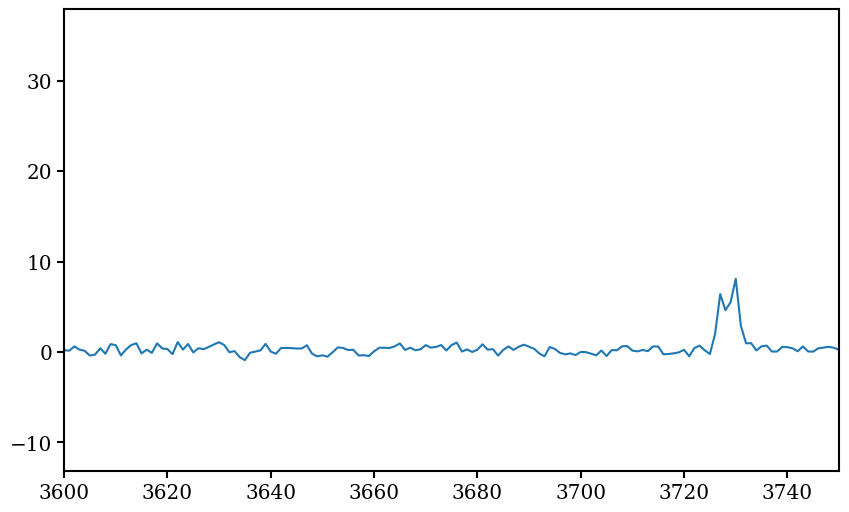

In [149]:
plt.figure(figsize = (10,6))
plt.plot(wave_out, clean_flux[0])
plt.xlim([3600,3750])
plt.show()

In [150]:
## read the halpha flux measured using fastspecfit on the de-redshift spectrum!!
## this should roughly agree with my 

fspec_dered_meas = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/stackfit_individual_spectra_elg_dered.fits", hdu=3)


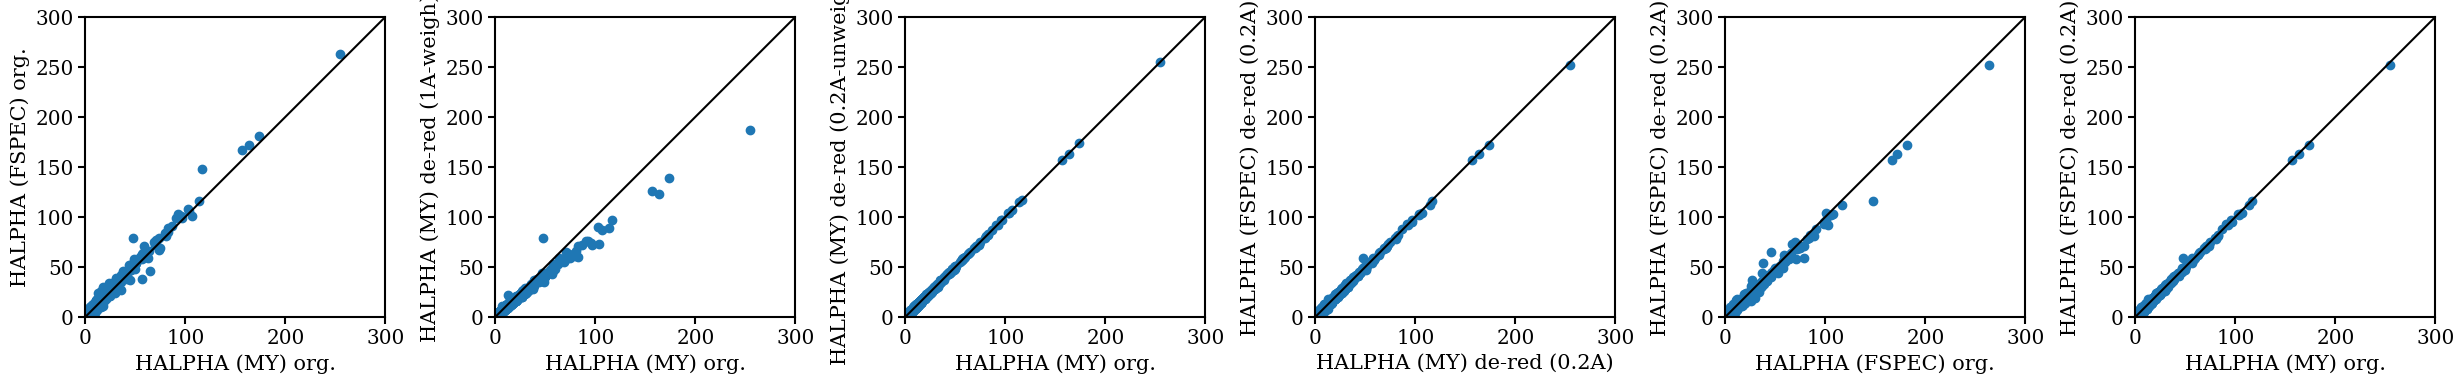

In [151]:
fig,ax = make_subplots(ncol=6,nrow=1,return_fig=True)

ax[0].scatter(halpha_org_spec,  elg_sub_cat_i["HALPHA_FLUX"] )
ax[0].set_xlabel("HALPHA (MY) org.",fontsize =15)
ax[0].set_ylabel("HALPHA (FSPEC) org.",fontsize =15)

ax[1].scatter(halpha_org_spec,  halpha_dered_spec )
ax[1].set_xlabel("HALPHA (MY) org.",fontsize =15)
ax[1].set_ylabel("HALPHA (MY) de-red (1A-weigh)",fontsize =15)

ax[2].scatter(halpha_org_spec,  halpha_dered_new_spec )
ax[2].set_xlabel("HALPHA (MY) org.",fontsize =15)
ax[2].set_ylabel("HALPHA (MY) de-red (0.2A-unweigh)",fontsize =15)

ax[3].scatter(halpha_dered_new_spec, fspec_dered_meas["HALPHA_FLUX"]    )
ax[3].set_xlabel("HALPHA (MY) de-red (0.2A)",fontsize =15)
ax[3].set_ylabel("HALPHA (FSPEC) de-red (0.2A)",fontsize =15)

ax[4].scatter(elg_sub_cat_i["HALPHA_FLUX"], fspec_dered_meas["HALPHA_FLUX"]  )
ax[4].set_xlabel("HALPHA (FSPEC) org.",fontsize =15)
ax[4].set_ylabel("HALPHA (FSPEC) de-red (0.2A)",fontsize =15)

ax[5].scatter(halpha_org_spec, fspec_dered_meas["HALPHA_FLUX"]  )
ax[5].set_xlabel("HALPHA (MY) org.",fontsize =15)
ax[5].set_ylabel("HALPHA (FSPEC) de-red (0.2A)",fontsize =15)


for axi in ax:
    axi.set_xlim([0,300])
    axi.set_ylim([0,300])
    axi.plot([0,300],[0,300],color="k")
    
plt.show()



What am i see: So if I do inverse variance weighted resampling of flux, I get a different slope between original spectra and the de-redshifted spectra. However, if I do unweighted resampling, then it is conserved well!! So the bottom line is to just unweighted resampling!


testing that we have done the de-redshifting correctly! Meausure the line fluxes on this spectra (boxflux is fine) and compare with fastspec flux!

100%|██████████| 1273/1273 [00:00<00:00, 1420.37it/s]


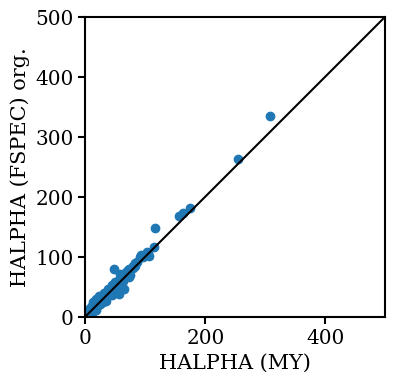

In [57]:
halpha_org_spec = []
halpha_dered_spec = []

for spec_ind in trange(len(elg_sub_cat_i)):
    halpha_org_spec.append(elg_sub_cat_i["HALPHA_FLUX"])

    #measure line flux on de-redshifted spectra!!
    temp = measure_all_lines_boxcar(wave, flux_elg_i[spec_ind], LINE_WINDOWS)

    halpha_dered_spec.append(temp["Halpha_flux"])


fig,ax = make_subplots(ncol=1,nrow=1,return_fig=True)

ax[0].scatter(halpha_dered_spec,  elg_sub_cat_i["HALPHA_FLUX"].data )
ax[0].set_xlabel("HALPHA (MY)",fontsize =15)
ax[0].set_ylabel("HALPHA (FSPEC) org.",fontsize =15)

for axi in ax:
    axi.set_xlim([0,500])
    axi.set_ylim([0,500])
    axi.plot([0,500],[0,500],color="k")
    
plt.show()

##YAY!! THESE AGREE! That is a good sign!


## Constructing the stacked spectra to run on fastspecfit

Run this stack on both bins of redshift and stellar mass and see what happens!!


In [14]:
zred_bins = np.concatenate( [ np.arange(0.01, 0.15, 0.01) , np.arange(0.15, 0.35,0.05) ] )

zcens = 0.5 * (zred_bins[1:] + zred_bins[:-1])

from elg_explore import measure_all_lines_boxcar, compute_line_ratios_bootstrap

In [15]:
print(zred_bins)

[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.2  0.25 0.3 ]


Total number selected = 68
Total number selected = 7389
Computing NO-ELG stack for z=[0.010, 0.020]
    Catalog normalization: 7389/7389 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.010_0.020.pkl


/tmp/ipykernel_9913/2318910251.py:133: RuntimeWarning: All-NaN slice encountered
  axi.set_ylim([0, np.nanmax(stack_spec_elg) * 1.1])


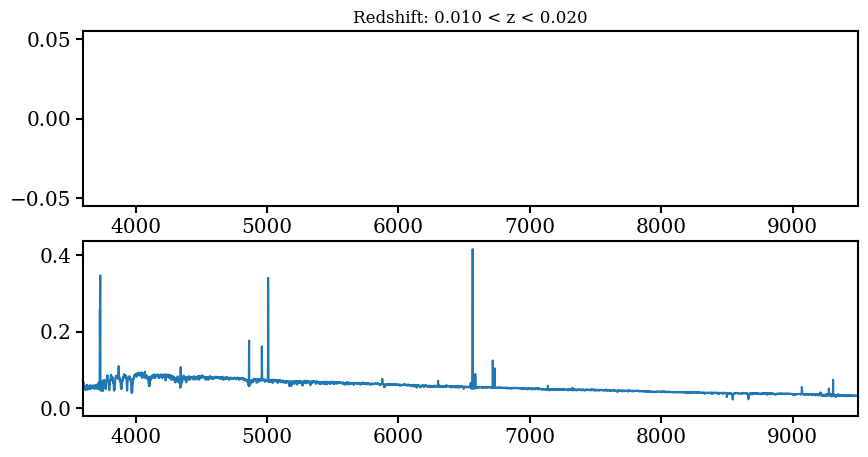

--
Total number selected = 241
Total number selected = 17963
Computing NO-ELG stack for z=[0.020, 0.030]
    Catalog normalization: 17963/17963 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.020_0.030.pkl


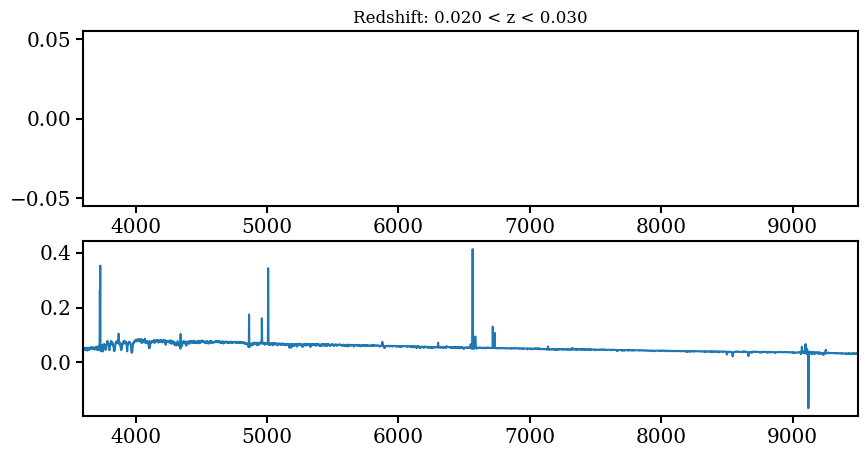

--
Total number selected = 535
Total number selected = 25628
Computing ELG stack for z=[0.030, 0.040]
    Catalog normalization: 535/535 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.030_0.040.pkl
Computing NO-ELG stack for z=[0.030, 0.040]
    Catalog normalization: 25628/25628 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.030_0.040.pkl


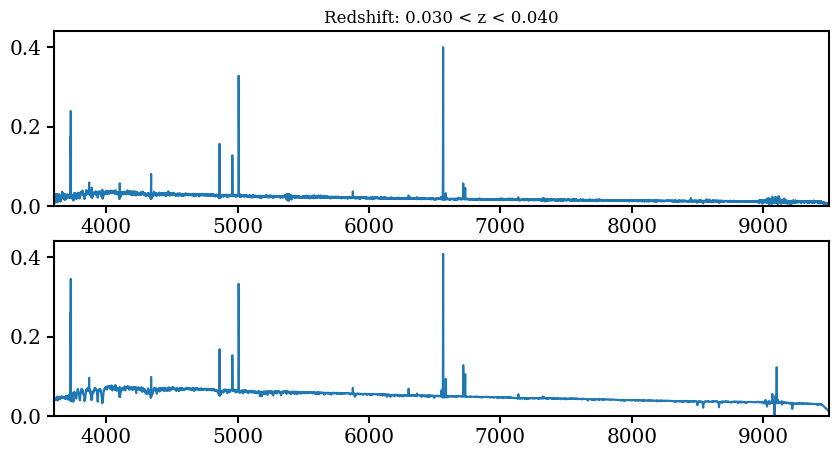

--
Total number selected = 888
Total number selected = 25113
Computing ELG stack for z=[0.040, 0.050]
    Catalog normalization: 888/888 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.040_0.050.pkl
Computing NO-ELG stack for z=[0.040, 0.050]
    Catalog normalization: 25113/25113 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.040_0.050.pkl


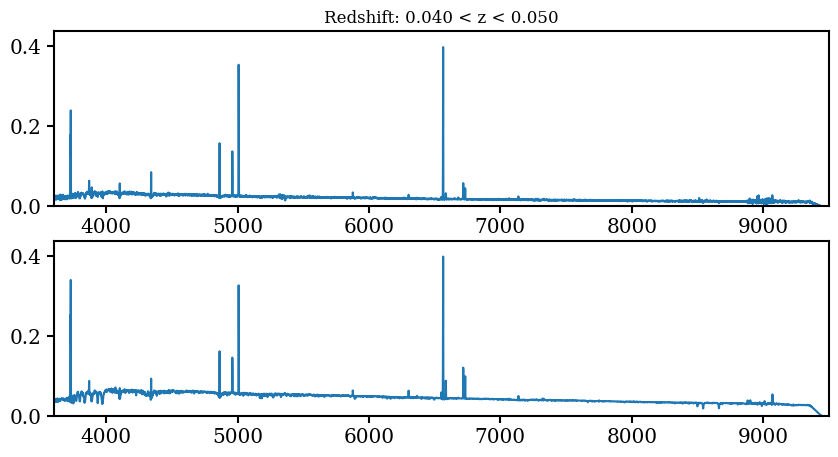

--
Total number selected = 1273
Total number selected = 25300
Computing ELG stack for z=[0.050, 0.060]
    Catalog normalization: 1273/1273 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.050_0.060.pkl
Computing NO-ELG stack for z=[0.050, 0.060]
    Catalog normalization: 25300/25300 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.050_0.060.pkl


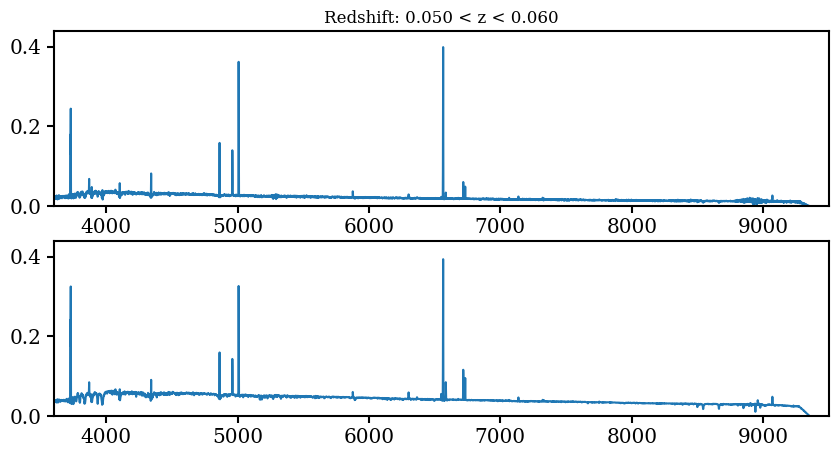

--
Total number selected = 2055
Total number selected = 23901
Computing ELG stack for z=[0.060, 0.070]
    Catalog normalization: 2055/2055 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.060_0.070.pkl
Computing NO-ELG stack for z=[0.060, 0.070]
    Catalog normalization: 23901/23901 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.060_0.070.pkl


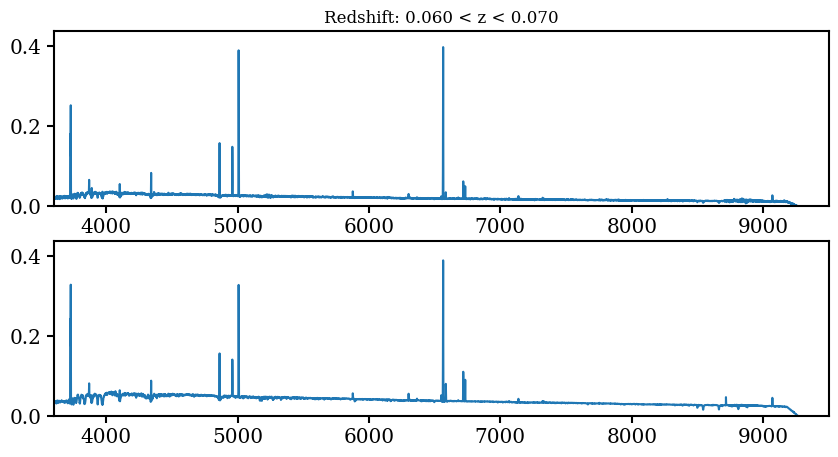

--
Total number selected = 3576
Total number selected = 20737
Computing ELG stack for z=[0.070, 0.080]
    Catalog normalization: 3576/3576 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.070_0.080.pkl
Computing NO-ELG stack for z=[0.070, 0.080]
    Catalog normalization: 20737/20737 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.070_0.080.pkl


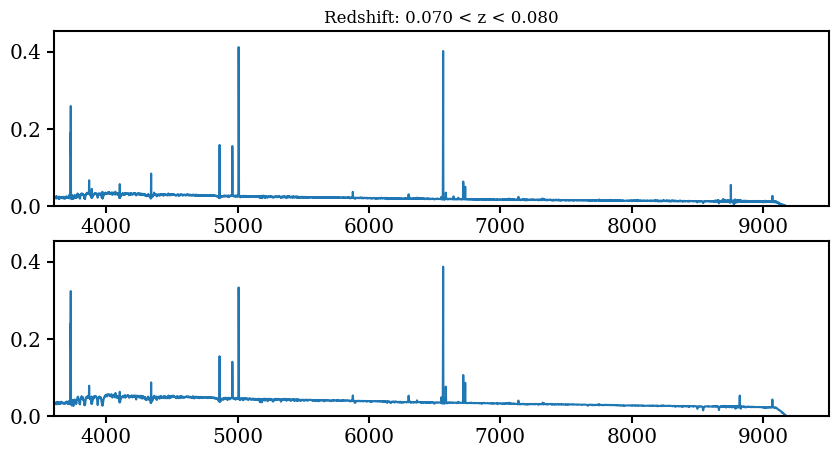

--
Total number selected = 5679
Total number selected = 16743
Computing ELG stack for z=[0.080, 0.090]
    Catalog normalization: 5679/5679 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.080_0.090.pkl
Computing NO-ELG stack for z=[0.080, 0.090]
    Catalog normalization: 16743/16743 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.080_0.090.pkl


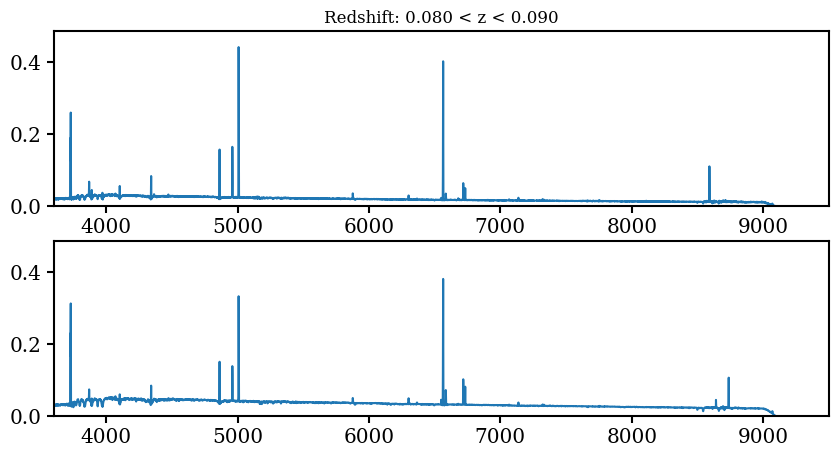

--
Total number selected = 9760
Total number selected = 10851
Computing ELG stack for z=[0.090, 0.100]
    Catalog normalization: 9760/9760 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.090_0.100.pkl
Computing NO-ELG stack for z=[0.090, 0.100]
    Catalog normalization: 10851/10851 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.090_0.100.pkl


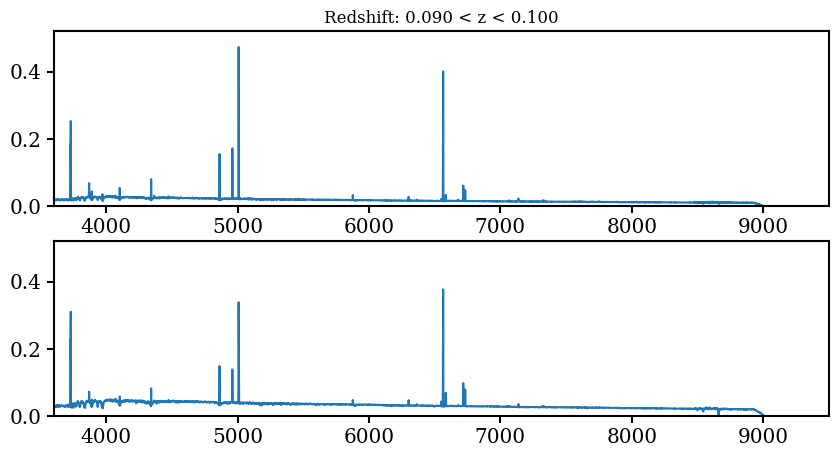

--
Total number selected = 9186
Total number selected = 6696
Computing ELG stack for z=[0.100, 0.110]
    Catalog normalization: 9186/9186 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.100_0.110.pkl
Computing NO-ELG stack for z=[0.100, 0.110]
    Catalog normalization: 6696/6696 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.100_0.110.pkl


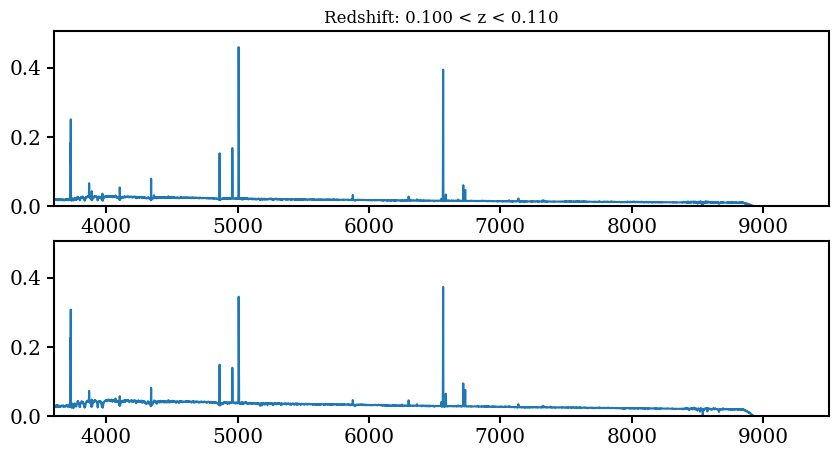

--
Total number selected = 9111
Total number selected = 4240
Computing ELG stack for z=[0.110, 0.120]
    Catalog normalization: 9111/9111 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.110_0.120.pkl
Computing NO-ELG stack for z=[0.110, 0.120]
    Catalog normalization: 4240/4240 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.110_0.120.pkl


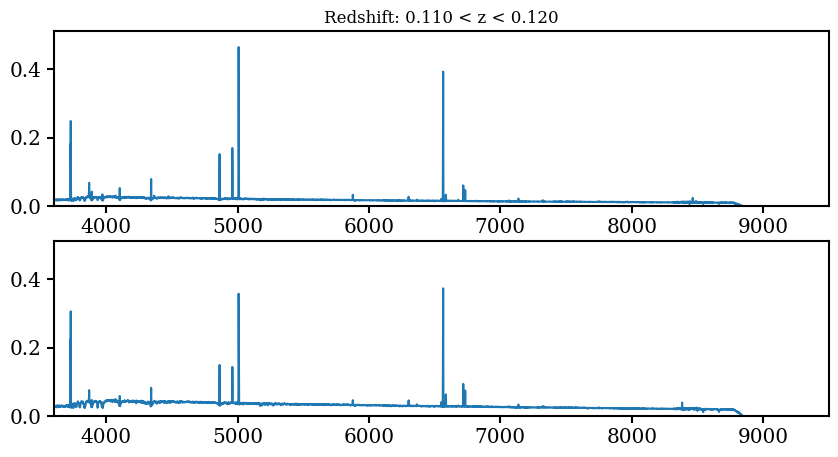

--
Total number selected = 9574
Total number selected = 2824
Computing ELG stack for z=[0.120, 0.130]
    Catalog normalization: 9574/9574 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.120_0.130.pkl
Computing NO-ELG stack for z=[0.120, 0.130]
    Catalog normalization: 2824/2824 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.120_0.130.pkl


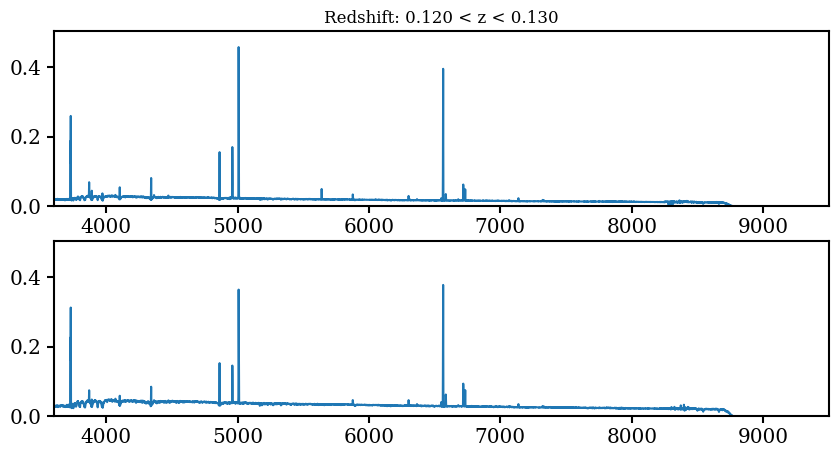

--
Total number selected = 6812
Total number selected = 1384
Computing ELG stack for z=[0.130, 0.140]
    Catalog normalization: 6812/6812 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.130_0.140.pkl
Computing NO-ELG stack for z=[0.130, 0.140]
    Catalog normalization: 1384/1384 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.130_0.140.pkl


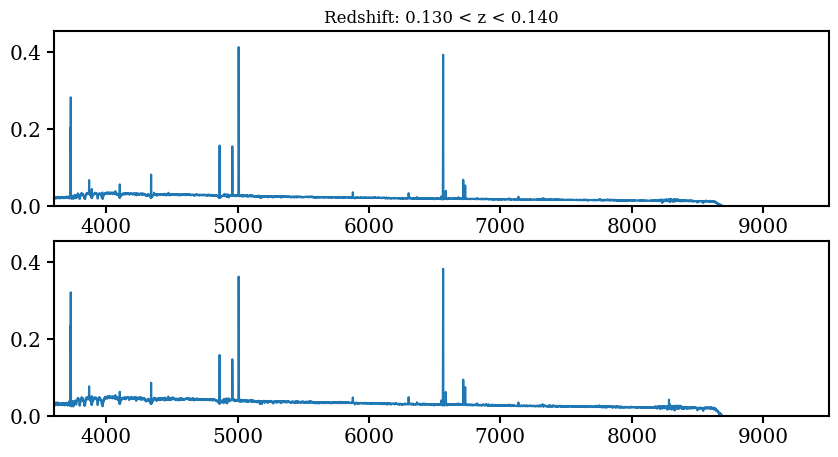

--
Total number selected = 5254
Total number selected = 619
Computing ELG stack for z=[0.140, 0.150]
    Catalog normalization: 5254/5254 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.140_0.150.pkl
Computing NO-ELG stack for z=[0.140, 0.150]
    Catalog normalization: 619/619 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_noelg_0.140_0.150.pkl


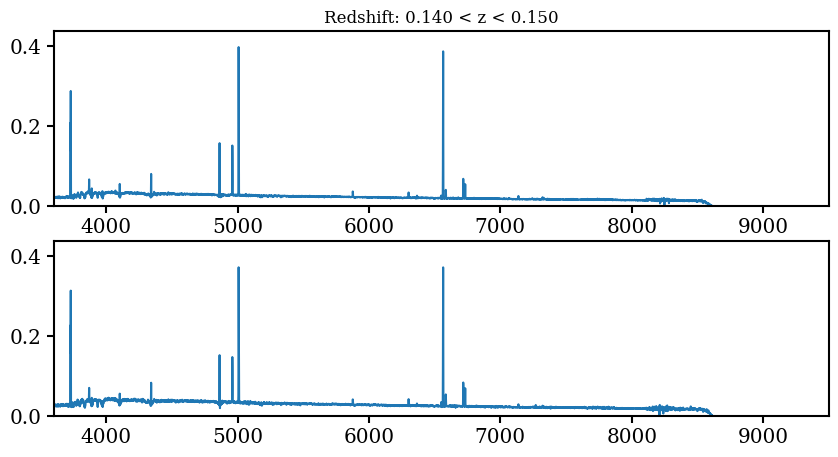

--
Total number selected = 20846
Total number selected = 330
Computing ELG stack for z=[0.150, 0.200]
    Catalog normalization: 20846/20846 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.150_0.200.pkl


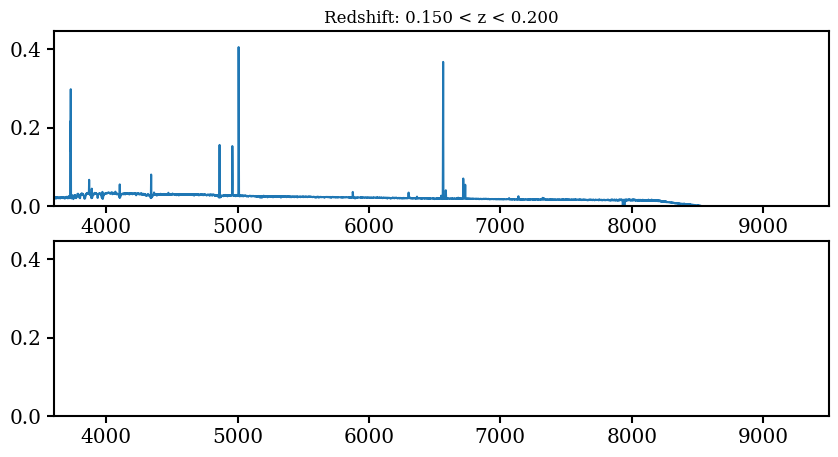

--
Total number selected = 19110
Total number selected = 0
Computing ELG stack for z=[0.200, 0.250]
    Catalog normalization: 19110/19110 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.200_0.250.pkl


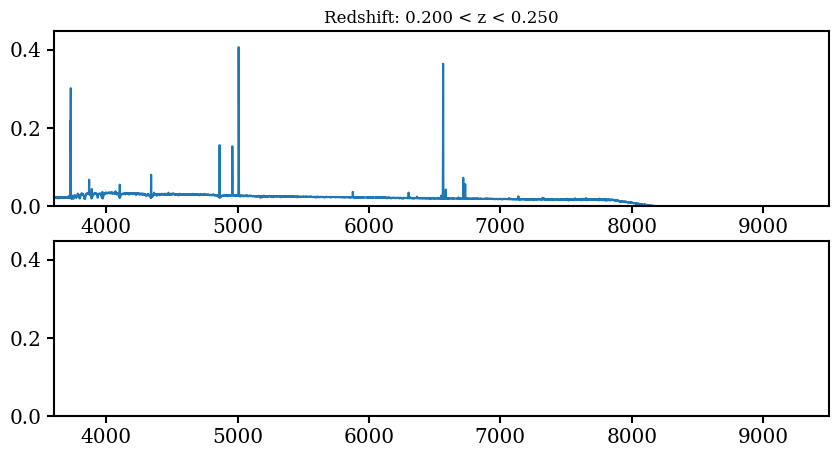

--
Total number selected = 13894
Total number selected = 0
Computing ELG stack for z=[0.250, 0.300]
    Catalog normalization: 13894/13894 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stacks_spec_elg_0.250_0.300.pkl


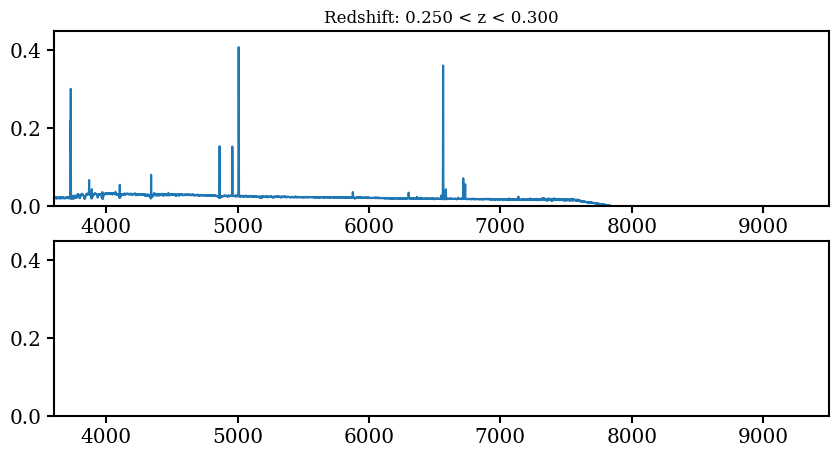

--


In [18]:
# =============================================================================
# Main loop
# =============================================================================
import pickle
from astropy.io import fits

stack_spec_elg_dict = {}
stack_spec_noelg_dict = {}
line_ratios_elg_dict = {}
line_ratios_noelg_dict = {}
overwrite = True

stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/"

# Create directory if it doesn't exist
os.makedirs(stack_path, exist_ok=True)

for i in range(len(zred_bins) - 1):
    zmin_i = zred_bins[i]
    zmax_i = zred_bins[i + 1]
    
    elg_sub_cat_i = select_sample(tot_cat, "ELG", z_min=zmin_i, z_max=zmax_i)
    noelg_sub_cat_i = select_sample(tot_cat, "NO_ELG", z_min=zmin_i, z_max=zmax_i)
    
    stack_nlim = 500
    
    # ----------------------------
    # ELG stack
    # ----------------------------
    if len(elg_sub_cat_i) > stack_nlim:
        stack_file_elg = stack_path + f"stacks_spec_elg_{zmin_i:.3f}_{zmax_i:.3f}.pkl"
        
        if os.path.exists(stack_file_elg) and overwrite == False:
            print(f"Loading existing ELG stack for z=[{zmin_i:.3f}, {zmax_i:.3f}]")
            with open(stack_file_elg, 'rb') as f:
                saved_data = pickle.load(f)
                stack_spec_elg = saved_data['stack_spec']
                stack_err_elg = saved_data['stack_err']
                all_stacks_elg = saved_data['all_stacks']
        else:
            print(f"Computing ELG stack for z=[{zmin_i:.3f}, {zmax_i:.3f}]")

            flux_elg_i, ivar_elg_i, haf_elg_i, tgids_elg_i = get_sample_spectra_with_linenorm(
                elg_sub_cat_i, spectra_data, line_norm="HALPHA"
            )
            
            stack_spec_elg, stack_err_elg, all_stacks_elg = bootstrap_stack(
                fluxes = flux_elg_i, 
                ivars = ivar_elg_i, 
                wave = wave,
                norm_method = "catalog",
                catalog_line_fluxes = haf_elg_i)

            # Save the stacked spectra
            save_data = {
                'stack_spec': stack_spec_elg,
                'stack_err': stack_err_elg,
                'all_stacks': all_stacks_elg,
                'zmin': zmin_i,
                'zmax': zmax_i,
                'n_galaxies': len(elg_sub_cat_i)
            }
            with open(stack_file_elg, 'wb') as f:
                pickle.dump(save_data, f)
            print(f"Saved ELG stack to {stack_file_elg}")
            
        # Compute line ratios directly from bootstrap realizations
        line_ratios_elg_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_elg, LINE_WINDOWS
        )
    else:
        stack_spec_elg = np.full_like(wave, np.nan)
        line_ratios_elg_dict[i] = None
    
    # ----------------------------
    # NO-ELG stack
    # ----------------------------
    if len(noelg_sub_cat_i) > stack_nlim:
        stack_file_noelg = stack_path + f"stacks_spec_noelg_{zmin_i:.3f}_{zmax_i:.3f}.pkl"
        
        if os.path.exists(stack_file_noelg) and overwrite == False:
            print(f"Loading existing NO-ELG stack for z=[{zmin_i:.3f}, {zmax_i:.3f}]")
            with open(stack_file_noelg, 'rb') as f:
                saved_data = pickle.load(f)
                stack_spec_noelg = saved_data['stack_spec']
                stack_err_noelg = saved_data['stack_err']
                all_stacks_noelg = saved_data['all_stacks']
        else:
            print(f"Computing NO-ELG stack for z=[{zmin_i:.3f}, {zmax_i:.3f}]")
     
            flux_noelg_i, ivar_noelg_i, haf_noelg_i, tgids_noelg_i = get_sample_spectra_with_linenorm(
                noelg_sub_cat_i, spectra_data, line_norm="HALPHA"
            )
            
            stack_spec_noelg, stack_err_noelg, all_stacks_noelg = bootstrap_stack(
                fluxes = flux_noelg_i, 
                ivars = ivar_noelg_i, 
                wave = wave,
                norm_method = "catalog",
                catalog_line_fluxes = haf_noelg_i)
            
            # Save the stacked spectra
            save_data = {
                'stack_spec': stack_spec_noelg,
                'stack_err': stack_err_noelg,
                'all_stacks': all_stacks_noelg,
                'zmin': zmin_i,
                'zmax': zmax_i,
                'n_galaxies': len(noelg_sub_cat_i)
            }
            with open(stack_file_noelg, 'wb') as f:
                pickle.dump(save_data, f)
            print(f"Saved NO-ELG stack to {stack_file_noelg}")
            
        line_ratios_noelg_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_noelg, LINE_WINDOWS
        )
    else:
        stack_spec_noelg = np.full_like(wave, np.nan)
        line_ratios_noelg_dict[i] = None
    
    # Plot stacked spectra
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    ax[0].set_title(f"Redshift: {zmin_i:.3f} < z < {zmax_i:.3f}")
    ax[0].plot(wave, stack_spec_elg, label="ELG")
    ax[1].plot(wave, stack_spec_noelg, label="BGS BRIGHT")

    for axi in ax:
        axi.set_xlim([3600, 9500])
        
    try:
        for axi in ax:
            axi.set_ylim([0, np.nanmax(stack_spec_elg) * 1.1])
    except:
        pass
        
    plt.show()
    
    stack_spec_elg_dict[i] = stack_spec_elg
    stack_spec_noelg_dict[i] = stack_spec_noelg
    print("--")

In [19]:
from elg_explore import write_stacked_spectra

stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/"

# --- ELG stacks ---
elg_indices = [i for i in stack_spec_elg_dict if not np.all(np.isnan(stack_spec_elg_dict[i]))]
n_elg = len(elg_indices)

if n_elg > 0:
    n_wave = len(wave)
    all_flux = np.zeros((n_elg, n_wave))
    all_ivar = np.zeros((n_elg, n_wave))

    for j, i in enumerate(elg_indices):
        flux_i = stack_spec_elg_dict[i]
        # You'll need the errors too - if you saved them separately, use those
        # Otherwise load from pickle:
        zmin_i = zred_bins[i]
        zmax_i = zred_bins[i + 1]
        with open(stack_path + f"stacks_spec_elg_{zmin_i:.3f}_{zmax_i:.3f}.pkl", 'rb') as f:
            saved = pickle.load(f)
        err_i = saved['stack_err']
        ivar_i = np.where(err_i > 0, 1.0 / err_i**2, 0.0)

        all_flux[j] = np.where(np.isfinite(flux_i), flux_i, 0.0)
        all_ivar[j] = np.where(np.isfinite(ivar_i) & (all_flux[j] != 0), ivar_i, 0.0)

    write_stacked_spectra(
        outfile=stack_path + "stack_zred_bins_elg.fits",
        wave=wave,
        flux=all_flux,
        ivar=all_ivar,
        stackids=np.array(elg_indices),
        stack_redshift=np.zeros(n_elg),
    )

# --- NO-ELG stacks ---
noelg_indices = [i for i in stack_spec_noelg_dict if not np.all(np.isnan(stack_spec_noelg_dict[i]))]
n_noelg = len(noelg_indices)

if n_noelg > 0:
    n_wave = len(wave)
    all_flux = np.zeros((n_noelg, n_wave))
    all_ivar = np.zeros((n_noelg, n_wave))

    for j, i in enumerate(noelg_indices):
        flux_i = stack_spec_noelg_dict[i]
        zmin_i = zred_bins[i]
        zmax_i = zred_bins[i + 1]
        with open(stack_path + f"stacks_spec_noelg_{zmin_i:.3f}_{zmax_i:.3f}.pkl", 'rb') as f:
            saved = pickle.load(f)
        err_i = saved['stack_err']
        ivar_i = np.where(err_i > 0, 1.0 / err_i**2, 0.0)

        all_flux[j] = np.where(np.isfinite(flux_i), flux_i, 0.0)
        all_ivar[j] = np.where(np.isfinite(ivar_i) & (all_flux[j] != 0), ivar_i, 0.0)

    write_stacked_spectra(
        outfile=stack_path + "stack_zred_bins_noelg.fits",
        wave=wave,
        flux=all_flux,
        ivar=all_ivar,
        stackids=np.array(noelg_indices),
        stack_redshift=np.zeros(n_noelg),
    )

Saved 15 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stack_zred_bins_elg.fits
Saved 14 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/stack_zred_bins_noelg.fits


/tmp/ipykernel_9913/2153999472.py:23: RuntimeWarning: divide by zero encountered in true_divide
  ivar_i = np.where(err_i > 0, 1.0 / err_i**2, 0.0)
/tmp/ipykernel_9913/2153999472.py:53: RuntimeWarning: divide by zero encountered in true_divide
  ivar_i = np.where(err_i > 0, 1.0 / err_i**2, 0.0)


#Running fastspecfit on the stacks

- stackfit stack_zred_bins_noelg.fits -o fastspec_stack_zred_bins_noelg.fits --mp 16
- stackfit stack_zred_bins_elg.fits -o fastspec_stack_zred_bins_elg.fits --mp 16

In [50]:
stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/"

# --- ELG stacks ---

with open(stack_path + f"stacks_spec_elg_mstar_7.50_7.75.pkl", 'rb') as f:
    saved = pickle.load(f)

flux_mean = saved['stack_spec']


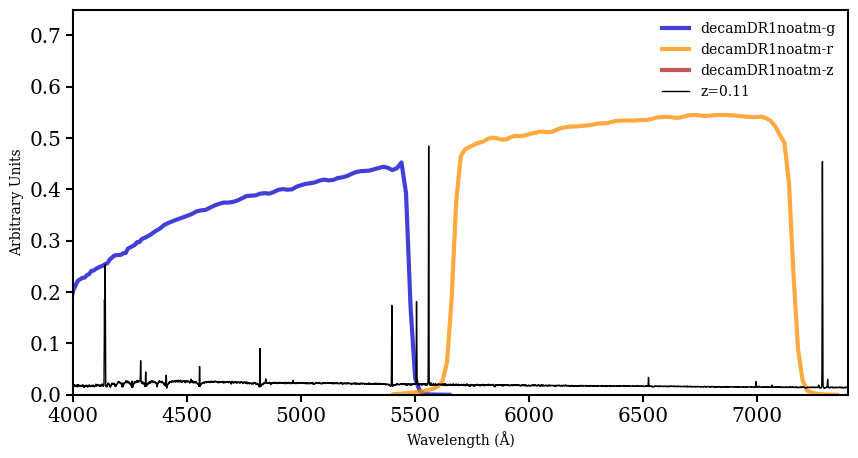

In [94]:
import speclite.filters
import matplotlib.pyplot as plt

# Load the filters
without_atm = speclite.filters.load_filters('decamDR1noatm-*')


plt.figure(figsize = (10,5) )

plot_filt = 0

color = ["mediumblue", "darkorange", "firebrick"]

# Each filter has .wavelength and .response attributes
for filt in without_atm:
    if filt.name in ['decamDR1noatm-g', 'decamDR1noatm-r', 'decamDR1noatm-z']:
        plt.plot(filt.wavelength, filt.response, alpha=0.75, lw =3, label=filt.name, color=color[plot_filt])
        plot_filt += 1

plt.plot(wave * (1+0.11), flux_mean, color="k",lw=1, label = "z=0.11")

# plt.plot(wave * (1+0.2), flux_mean+0.1, color="k",lw=1, label = "z=0.11")

plt.xlim([4000,7400])
plt.ylim([0,0.75])
plt.xlabel('Wavelength (Å)')
plt.ylabel('Arbitrary Units')
plt.legend()
plt.show()

In [30]:
# filt.wavelength, filt.response

# STELLAR MASS BINS STACKING NOW!

In [2]:
# Define stellar mass bins (0.25 dex bins)
# Adjust the range as needed for your data
mstar_bins = np.arange(6.0, 9.5, 0.25) 

stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/"


6.0 6.25
Total number selected = 29
Total number selected = 10
Skipping ELG for log(M*)=[6.00, 6.25] (N=29 < 500)
Skipping NO-ELG for log(M*)=[6.00, 6.25] (N=10 < 500)


/tmp/ipykernel_58281/1995235648.py:156: RuntimeWarning: All-NaN slice encountered
  axi.set_ylim([0, np.nanmax(stack_spec_elg) * 1.1])


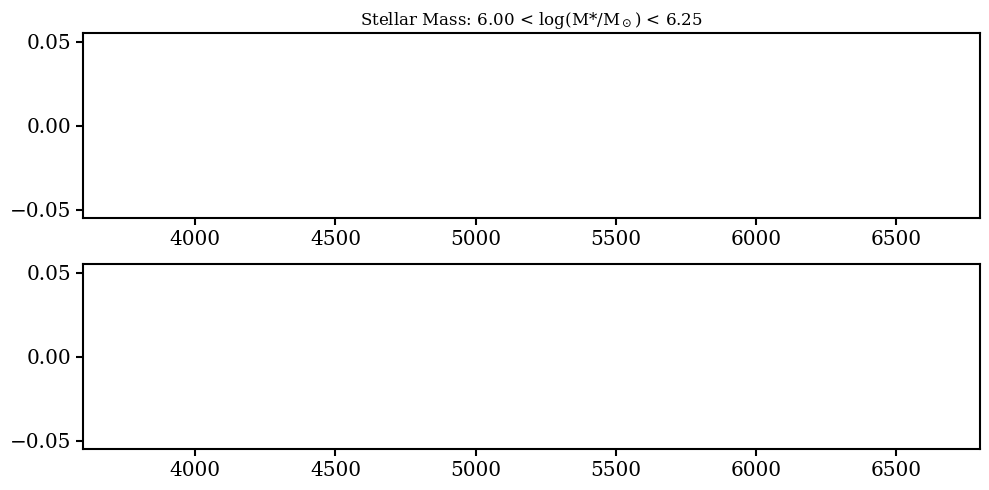

6.25 6.5
Total number selected = 65
Total number selected = 33
Skipping ELG for log(M*)=[6.25, 6.50] (N=65 < 500)
Skipping NO-ELG for log(M*)=[6.25, 6.50] (N=33 < 500)


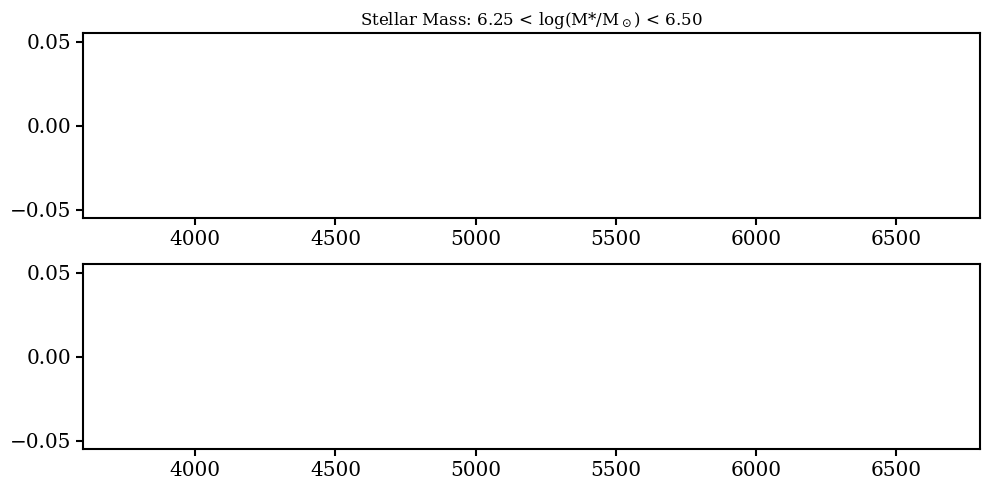

6.5 6.75
Total number selected = 241
Total number selected = 76
Skipping ELG for log(M*)=[6.50, 6.75] (N=241 < 500)
Skipping NO-ELG for log(M*)=[6.50, 6.75] (N=76 < 500)


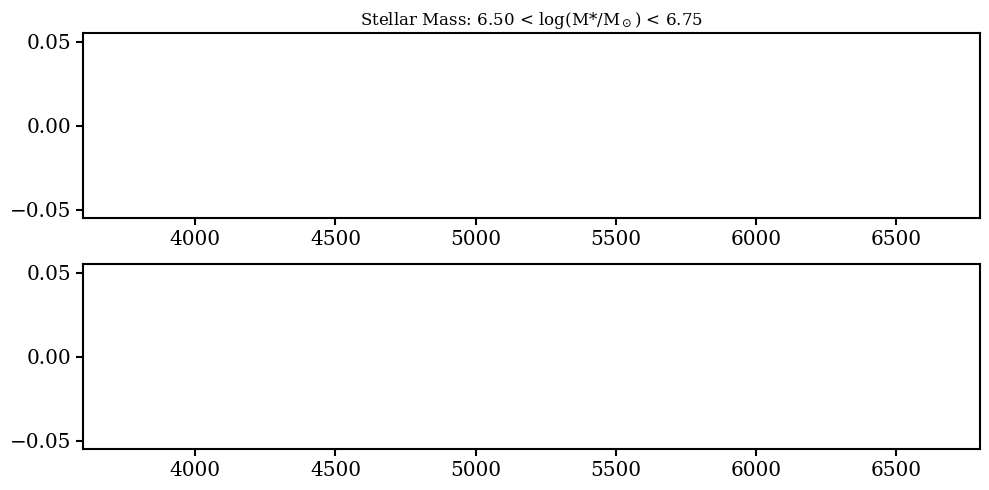

6.75 7.0
Total number selected = 751
Total number selected = 156
Computing ELG stack for log(M*)=[6.75, 7.00] (N=751)
NDRAW = 5000
    Catalog normalization: 751/751 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_6.75_7.00.pkl
Skipping NO-ELG for log(M*)=[6.75, 7.00] (N=156 < 500)


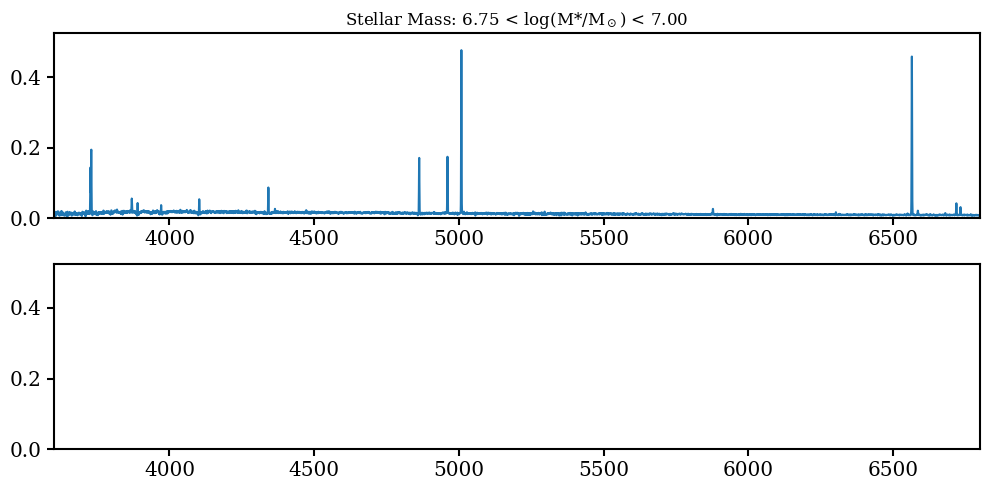

7.0 7.25
Total number selected = 1733
Total number selected = 397
Computing ELG stack for log(M*)=[7.00, 7.25] (N=1733)
NDRAW = 5000
    Catalog normalization: 1733/1733 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_7.00_7.25.pkl
Skipping NO-ELG for log(M*)=[7.00, 7.25] (N=397 < 500)


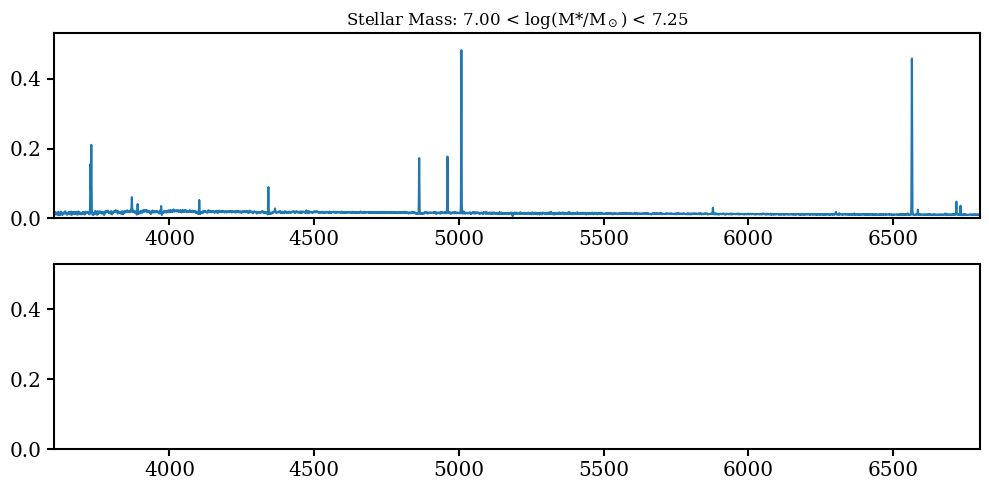

7.25 7.5
Total number selected = 4091
Total number selected = 905
Computing ELG stack for log(M*)=[7.25, 7.50] (N=4091)
NDRAW = 5000
    Catalog normalization: 4091/4091 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_7.25_7.50.pkl
Computing NO-ELG stack for log(M*)=[7.25, 7.50] (N=905)
NDRAW = 5000
    Catalog normalization: 905/905 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_noelg_mstar_7.25_7.50.pkl


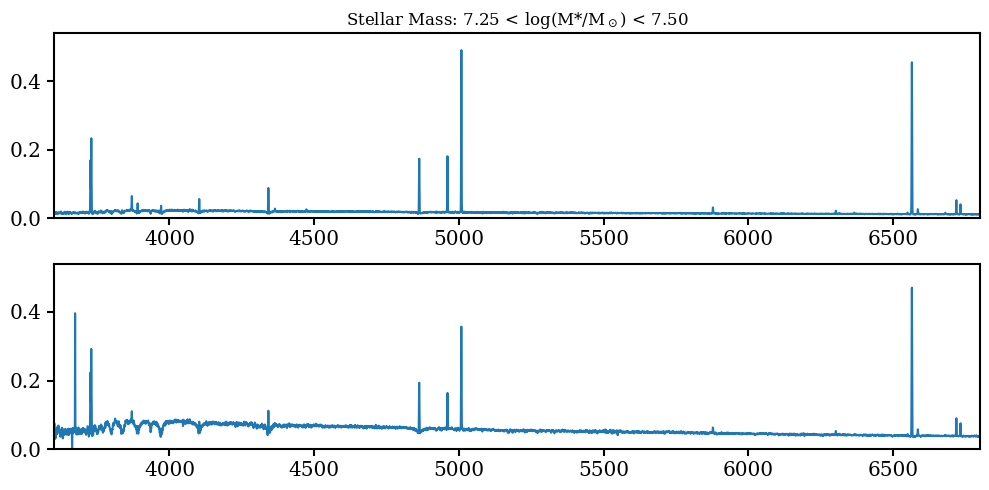

7.5 7.75
Total number selected = 8654
Total number selected = 1859
Computing ELG stack for log(M*)=[7.50, 7.75] (N=8654)
NDRAW = 5000
    Catalog normalization: 8654/8654 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_7.50_7.75.pkl
Computing NO-ELG stack for log(M*)=[7.50, 7.75] (N=1859)
NDRAW = 5000
    Catalog normalization: 1859/1859 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_noelg_mstar_7.50_7.75.pkl


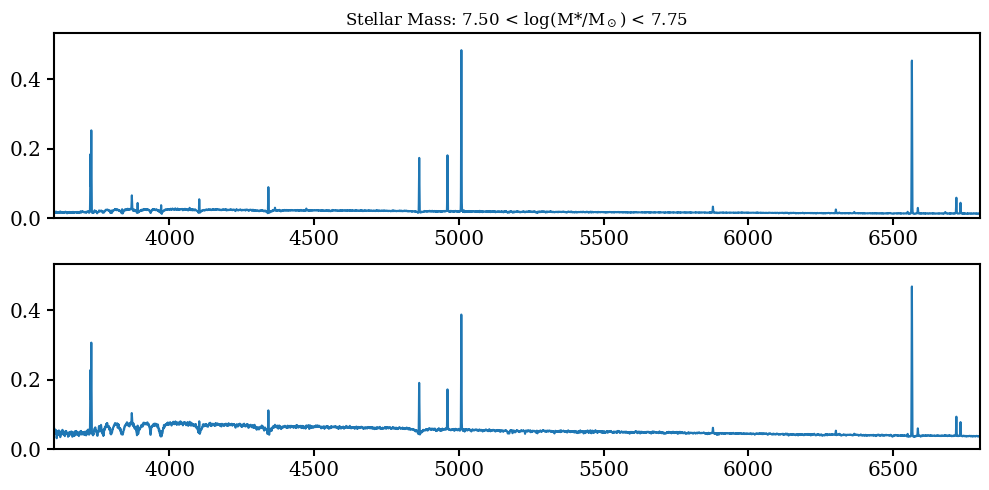

7.75 8.0
Total number selected = 15464
Total number selected = 3885
Computing ELG stack for log(M*)=[7.75, 8.00] (N=15464)
NDRAW = 5000
    Catalog normalization: 15464/15464 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_7.75_8.00.pkl
Computing NO-ELG stack for log(M*)=[7.75, 8.00] (N=3885)
NDRAW = 5000
    Catalog normalization: 3885/3885 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_noelg_mstar_7.75_8.00.pkl


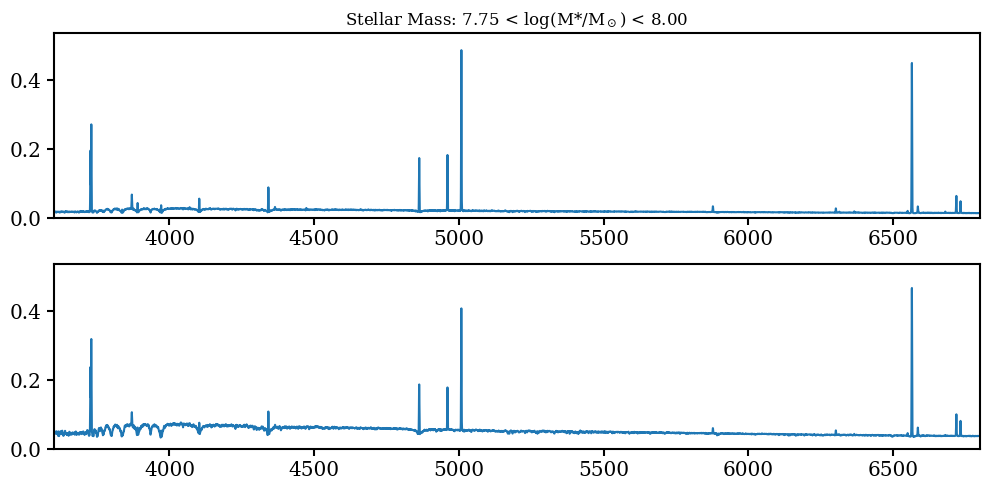

8.0 8.25
Total number selected = 22837
Total number selected = 8073
Computing ELG stack for log(M*)=[8.00, 8.25] (N=22837)
NDRAW = 5000
    Catalog normalization: 22837/22837 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_8.00_8.25.pkl
Computing NO-ELG stack for log(M*)=[8.00, 8.25] (N=8073)
NDRAW = 5000
    Catalog normalization: 8073/8073 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_noelg_mstar_8.00_8.25.pkl


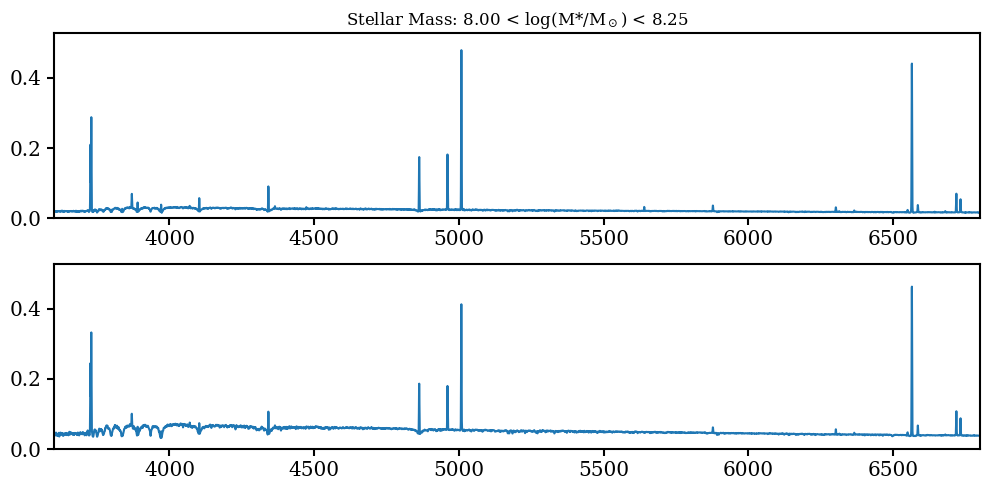

8.25 8.5
Total number selected = 25972
Total number selected = 15715
Computing ELG stack for log(M*)=[8.25, 8.50] (N=25972)
NDRAW = 5000
    Catalog normalization: 25972/25972 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_8.25_8.50.pkl
Computing NO-ELG stack for log(M*)=[8.25, 8.50] (N=15715)
NDRAW = 5000
    Catalog normalization: 15715/15715 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_noelg_mstar_8.25_8.50.pkl


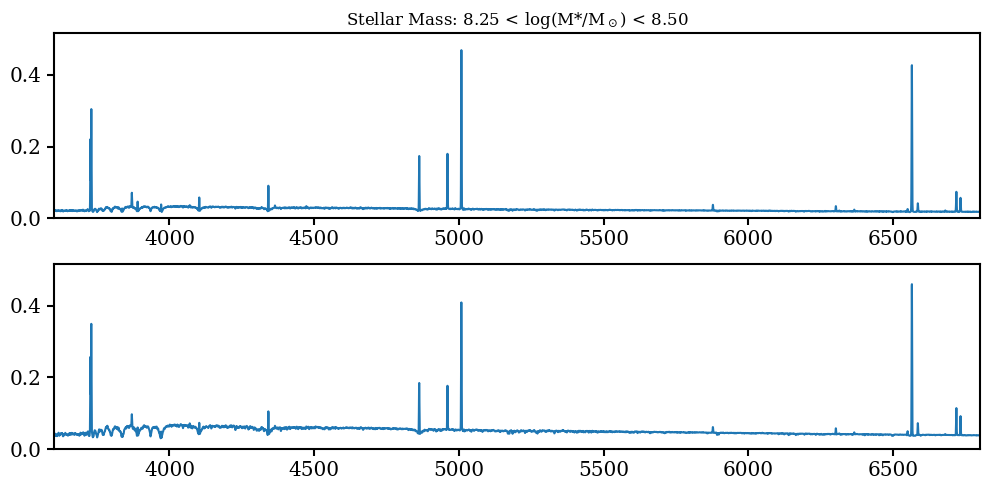

8.5 8.75
Total number selected = 24204
Total number selected = 29237
Computing ELG stack for log(M*)=[8.50, 8.75] (N=24204)
NDRAW = 5000
    Catalog normalization: 24204/24204 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_8.50_8.75.pkl
Computing NO-ELG stack for log(M*)=[8.50, 8.75] (N=29237)
NDRAW = 5000
    Catalog normalization: 29237/29237 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_noelg_mstar_8.50_8.75.pkl


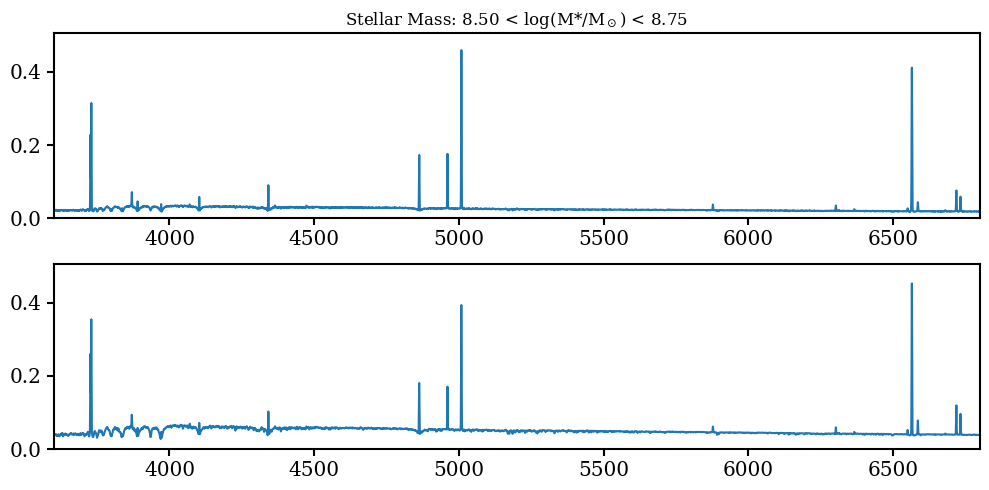

8.75 9.0
Total number selected = 19010
Total number selected = 49703
Computing ELG stack for log(M*)=[8.75, 9.00] (N=19010)
NDRAW = 5000
    Catalog normalization: 19010/19010 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_8.75_9.00.pkl
Computing NO-ELG stack for log(M*)=[8.75, 9.00] (N=49703)
NDRAW = 5000
    Catalog normalization: 49703/49703 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_noelg_mstar_8.75_9.00.pkl


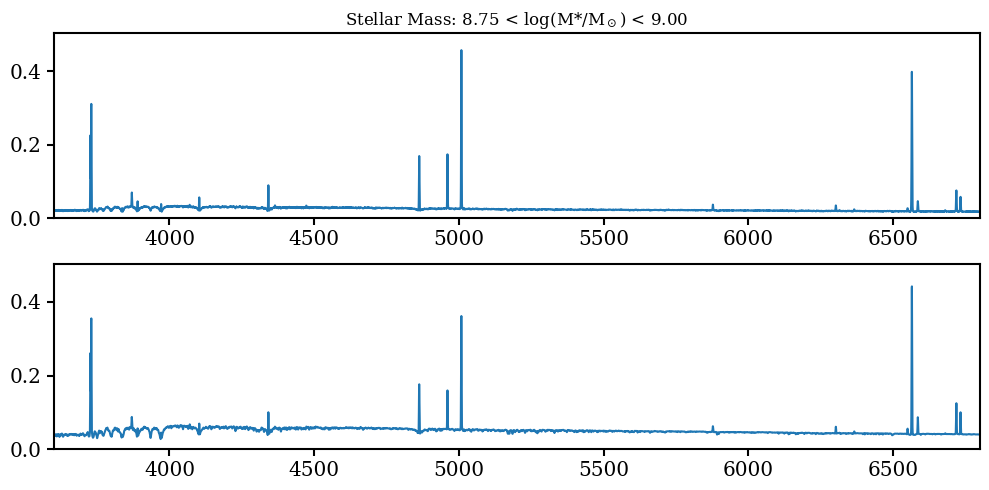

9.0 9.25
Total number selected = 13725
Total number selected = 81242
Computing ELG stack for log(M*)=[9.00, 9.25] (N=13725)
NDRAW = 5000
    Catalog normalization: 13725/13725 spectra with valid line flux
Saved ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_9.00_9.25.pkl
Computing NO-ELG stack for log(M*)=[9.00, 9.25] (N=81242)
NDRAW = 5000
    Catalog normalization: 81242/81242 spectra with valid line flux
Saved NO-ELG stack to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_noelg_mstar_9.00_9.25.pkl


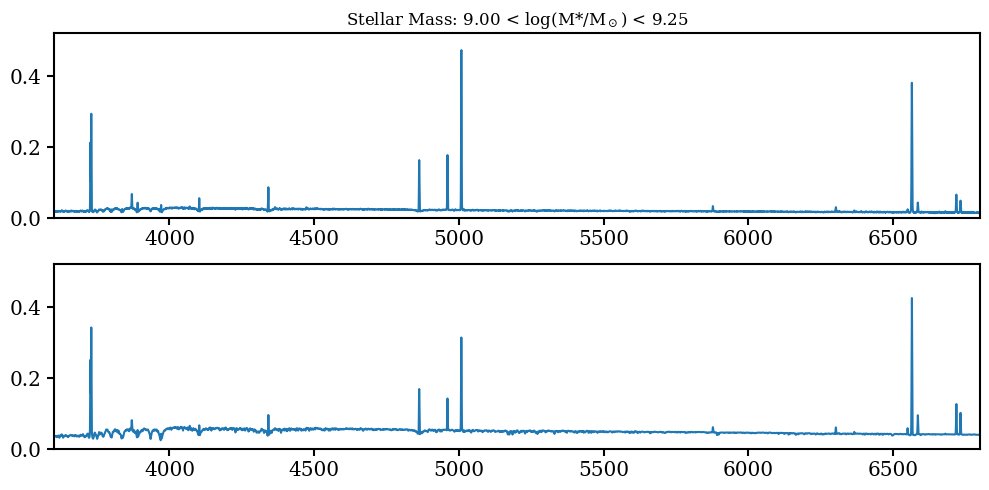

In [143]:
# =============================================================================
# Main loop - Stellar Mass Bins
# =============================================================================
import pickle
from astropy.io import fits

stack_spec_elg_mstar_dict = {}
stack_spec_noelg_mstar_dict = {}
line_ratios_elg_mstar_dict = {}
line_ratios_noelg_mstar_dict = {}
overwrite = False

# Create directory if it doesn't exist
os.makedirs(stack_path, exist_ok=True)


# Redshift range (no limit, but specify the full range)
z_min_global = 0.0
z_max_global = 0.5

for i in range(len(mstar_bins) - 1):
    mstar_min_i = mstar_bins[i]
    mstar_max_i = mstar_bins[i + 1]

    print(mstar_min_i, mstar_max_i)
    
    # Select samples in this stellar mass bin (across full redshift range)
    elg_sub_cat_i = select_sample(tot_cat, "ELG", z_min=z_min_global, z_max=z_max_global, 
                                   logmstar_min=mstar_min_i, logmstar_max=mstar_max_i)
    noelg_sub_cat_i = select_sample(tot_cat, "NO_ELG", z_min=z_min_global, z_max=z_max_global,
                                     logmstar_min=mstar_min_i, logmstar_max=mstar_max_i)
    
    stack_nlim = 500
    
    # ----------------------------
    # ELG stack
    # ----------------------------
    if len(elg_sub_cat_i) > stack_nlim:
        stack_file_elg = stack_path + f"stacks_spec_elg_mstar_{mstar_min_i:.2f}_{mstar_max_i:.2f}.pkl"
        
        if os.path.exists(stack_file_elg) and overwrite == False:
            print(f"Loading existing ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}]")
            with open(stack_file_elg, 'rb') as f:
                saved_data = pickle.load(f)
                stack_spec_elg = saved_data['stack_spec']
                stack_err_elg = saved_data['stack_err']
                all_stacks_elg = saved_data['all_stacks']
        else:
            print(f"Computing ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(elg_sub_cat_i)})")

            
            flux_elg_i, ivar_elg_i, haf_elg_i, tgids_elg_i = get_sample_spectra_with_linenorm(
                elg_sub_cat_i, spectra_data, line_norm="HALPHA"
            )
            
            stack_spec_elg, stack_err_elg, all_stacks_elg = bootstrap_stack(
                fluxes = flux_elg_i, 
                ivars = ivar_elg_i, 
                wave = wave,
                norm_method = "catalog",
                catalog_line_fluxes = haf_elg_i)
            
            # Save the stacked spectra
            save_data = {
                'stack_spec': stack_spec_elg,
                'stack_err': stack_err_elg,
                'all_stacks': all_stacks_elg,
                'mstar_min': mstar_min_i,
                'mstar_max': mstar_max_i,
                'z_min': z_min_global,
                'z_max': z_max_global,
                'n_galaxies': len(elg_sub_cat_i)
            }
            with open(stack_file_elg, 'wb') as f:
                pickle.dump(save_data, f)
            print(f"Saved ELG stack to {stack_file_elg}")
            
        # Compute line ratios directly from bootstrap realizations
        line_ratios_elg_mstar_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_elg, LINE_WINDOWS
        )
    else:
        print(f"Skipping ELG for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(elg_sub_cat_i)} < {stack_nlim})")
        stack_spec_elg = np.full_like(wave, np.nan)
        line_ratios_elg_mstar_dict[i] = None

    ##now let us do some more direct checks?
    
    # ----------------------------
    # NO-ELG stack
    # ----------------------------
    if len(noelg_sub_cat_i) > stack_nlim:
        stack_file_noelg = stack_path + f"stacks_spec_noelg_mstar_{mstar_min_i:.2f}_{mstar_max_i:.2f}.pkl"
        
        if os.path.exists(stack_file_noelg) and overwrite == False:
            print(f"Loading existing NO-ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}]")
            with open(stack_file_noelg, 'rb') as f:
                saved_data = pickle.load(f)
                stack_spec_noelg = saved_data['stack_spec']
                stack_err_noelg = saved_data['stack_err']
                all_stacks_noelg = saved_data['all_stacks']
        else:
            print(f"Computing NO-ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(noelg_sub_cat_i)})")

            flux_noelg_i, ivar_noelg_i, haf_noelg_i, tgids_noelg_i = get_sample_spectra_with_linenorm(
                noelg_sub_cat_i, spectra_data, line_norm="HALPHA"
            )
            
            stack_spec_noelg, stack_err_noelg, all_stacks_noelg = bootstrap_stack(
                fluxes = flux_noelg_i, 
                ivars = ivar_noelg_i, 
                wave = wave,
                norm_method = "catalog",
                catalog_line_fluxes = haf_noelg_i)
    
            # Save the stacked spectra
            save_data = {
                'stack_spec': stack_spec_noelg,
                'stack_err': stack_err_noelg,
                'all_stacks': all_stacks_noelg,
                'mstar_min': mstar_min_i,
                'mstar_max': mstar_max_i,
                'z_min': z_min_global,
                'z_max': z_max_global,
                'n_galaxies': len(noelg_sub_cat_i)
            }
            with open(stack_file_noelg, 'wb') as f:
                pickle.dump(save_data, f)
            print(f"Saved NO-ELG stack to {stack_file_noelg}")
            
        line_ratios_noelg_mstar_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_noelg, LINE_WINDOWS
        )
    else:
        print(f"Skipping NO-ELG for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(noelg_sub_cat_i)} < {stack_nlim})")
        stack_spec_noelg = np.full_like(wave, np.nan)
        line_ratios_noelg_mstar_dict[i] = None

    stack_spec_elg_mstar_dict[i] = stack_spec_elg
    stack_spec_noelg_mstar_dict[i] = stack_spec_noelg
    
    # Plot stacked spectra
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    ax[0].set_title(f"Stellar Mass: {mstar_min_i:.2f} < log(M*/M$_\\odot$) < {mstar_max_i:.2f}")
    ax[0].plot(wave, stack_spec_elg, label="ELG")
    ax[1].plot(wave, stack_spec_noelg, label="BGS BRIGHT")

    for axi in ax:
        axi.set_xlim([3600, 6800])        
    try:
        for axi in ax:
            axi.set_ylim([0, np.nanmax(stack_spec_elg) * 1.1])
    except:
        pass
        
    plt.tight_layout()
    plt.show()
    

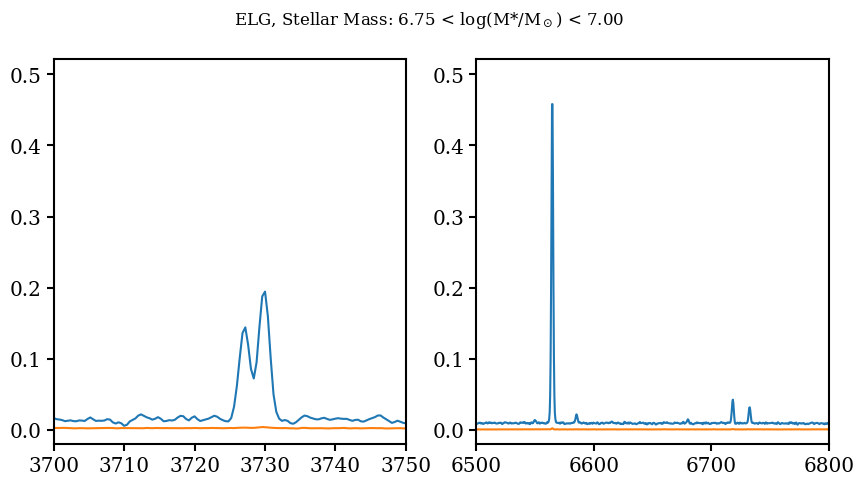

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_6.75_7.00.fits
(51, 8000) (8000,)
Saved ELG mstar bin [6.75, 7.00]: 1 mean + 50 bootstraps


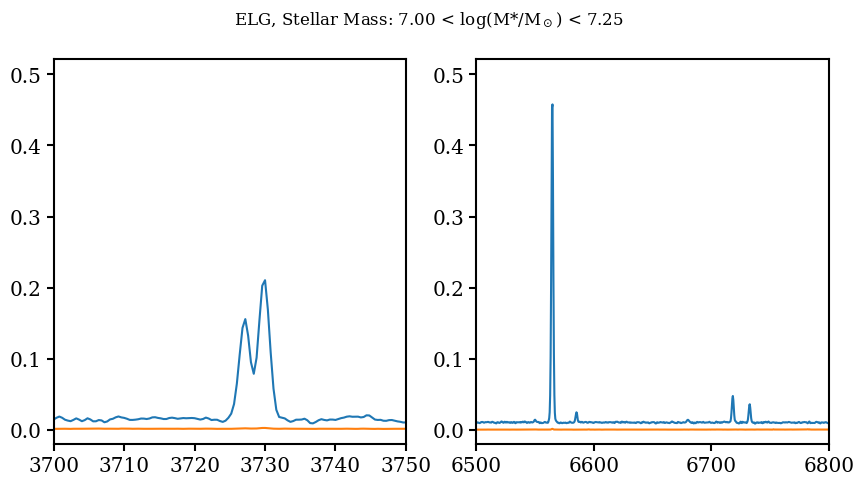

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_7.00_7.25.fits
(51, 8000) (8000,)
Saved ELG mstar bin [7.00, 7.25]: 1 mean + 50 bootstraps


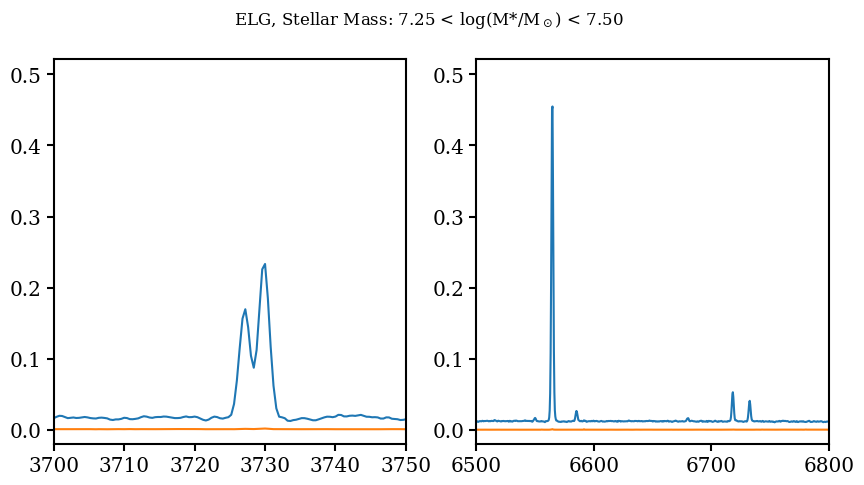

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_7.25_7.50.fits
(51, 8000) (8000,)
Saved ELG mstar bin [7.25, 7.50]: 1 mean + 50 bootstraps


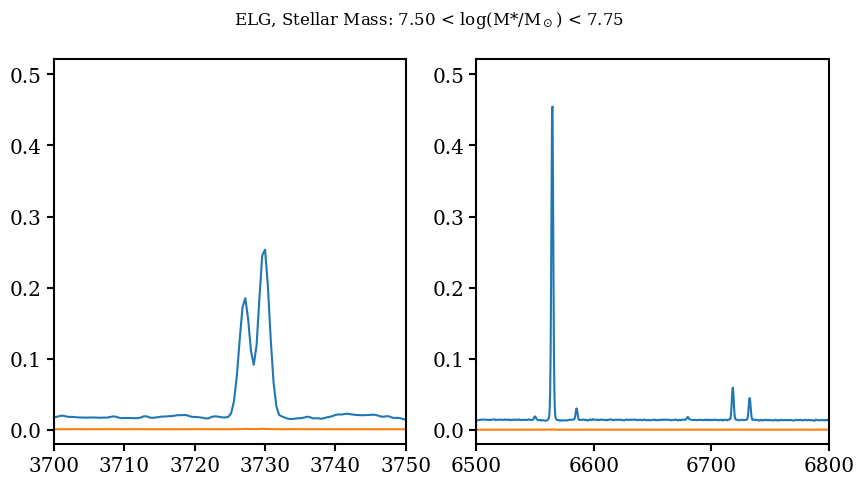

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_7.50_7.75.fits
(51, 8000) (8000,)
Saved ELG mstar bin [7.50, 7.75]: 1 mean + 50 bootstraps


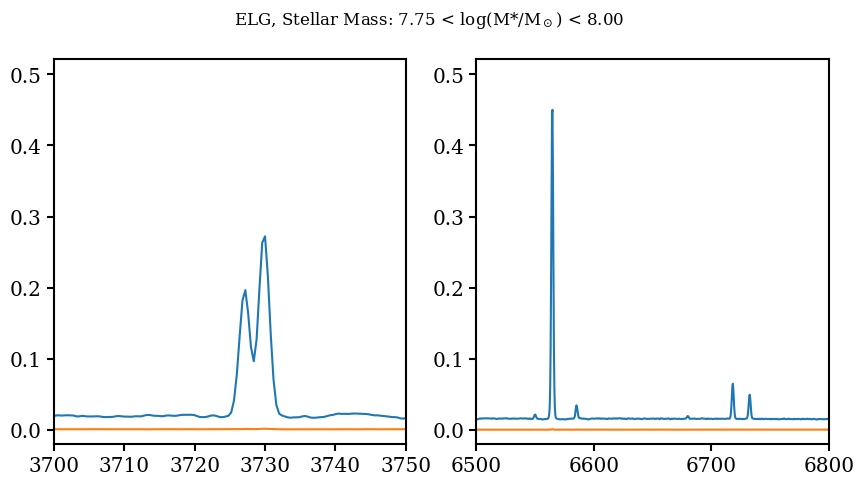

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_7.75_8.00.fits
(51, 8000) (8000,)
Saved ELG mstar bin [7.75, 8.00]: 1 mean + 50 bootstraps


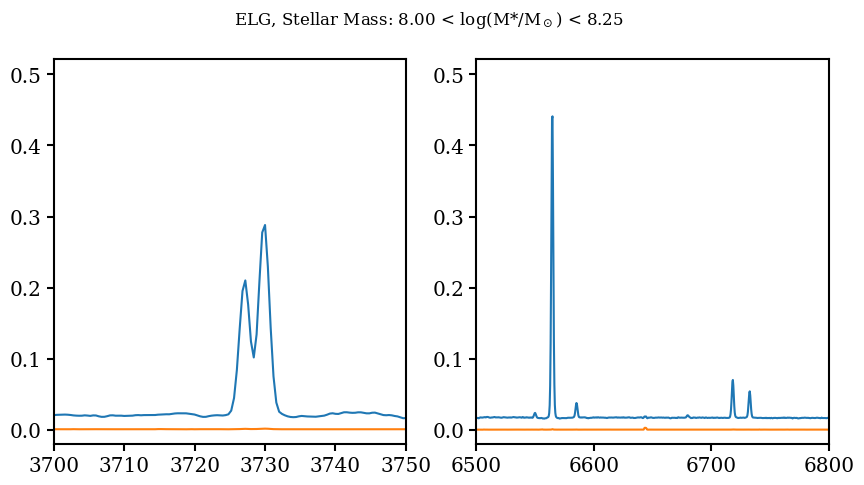

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_8.00_8.25.fits
(51, 8000) (8000,)
Saved ELG mstar bin [8.00, 8.25]: 1 mean + 50 bootstraps


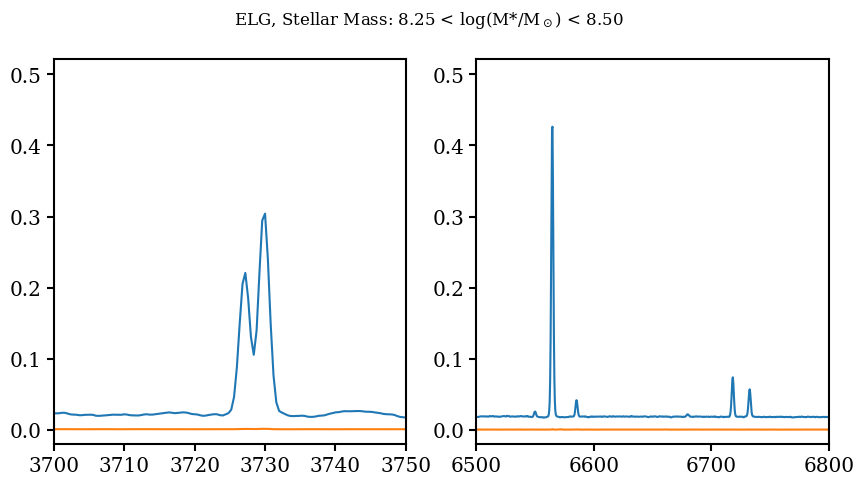

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_8.25_8.50.fits
(51, 8000) (8000,)
Saved ELG mstar bin [8.25, 8.50]: 1 mean + 50 bootstraps


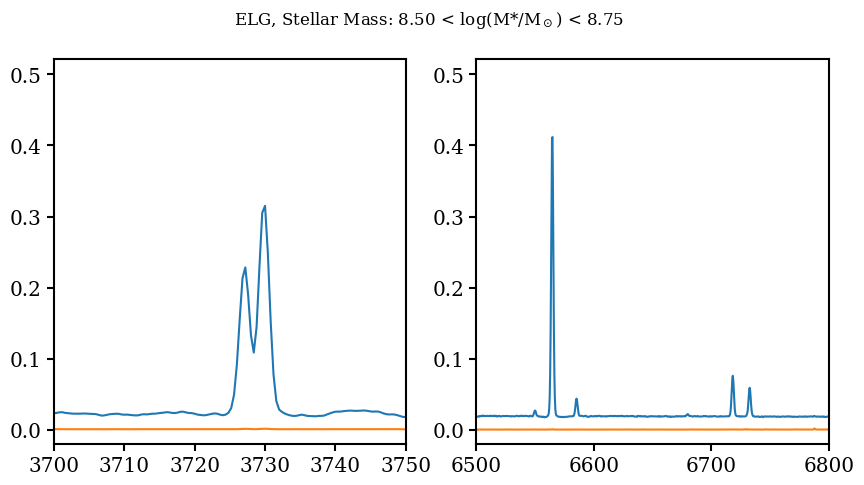

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_8.50_8.75.fits
(51, 8000) (8000,)
Saved ELG mstar bin [8.50, 8.75]: 1 mean + 50 bootstraps


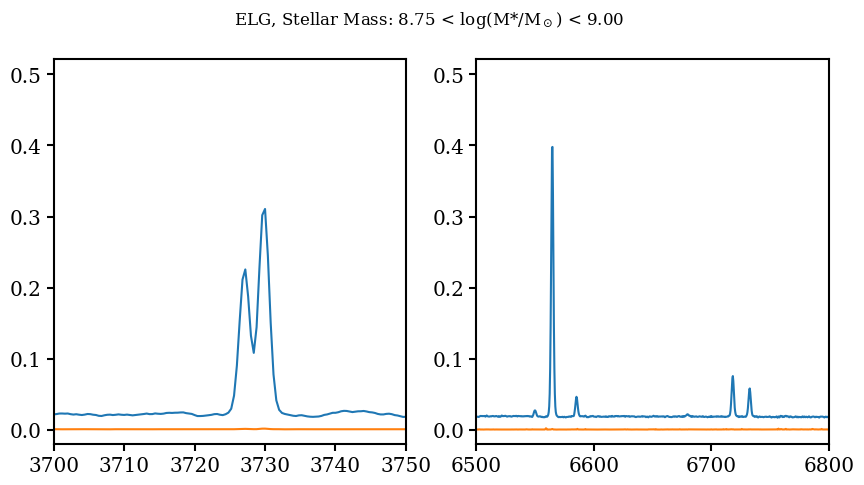

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_8.75_9.00.fits
(51, 8000) (8000,)
Saved ELG mstar bin [8.75, 9.00]: 1 mean + 50 bootstraps


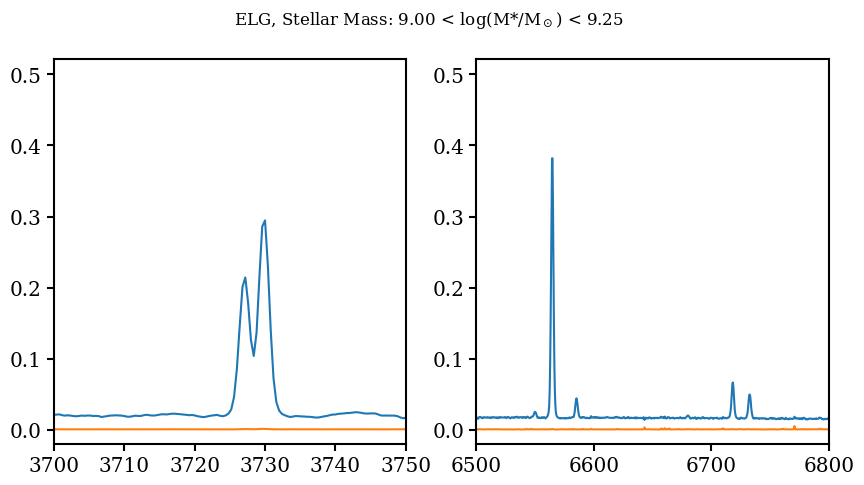

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_9.00_9.25.fits
(51, 8000) (8000,)
Saved ELG mstar bin [9.00, 9.25]: 1 mean + 50 bootstraps


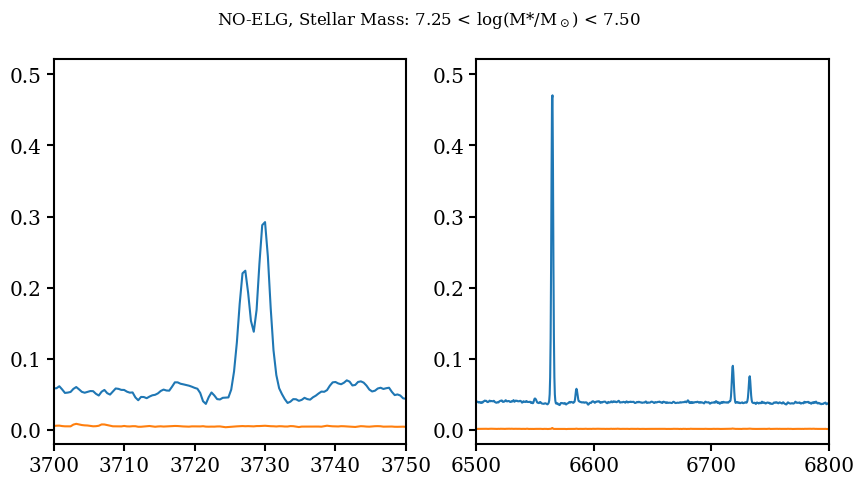

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_noelg_7.25_7.50.fits
(51, 8000) (8000,)
Saved NO-ELG mstar bin [7.25, 7.50]: 1 mean + 50 bootstraps


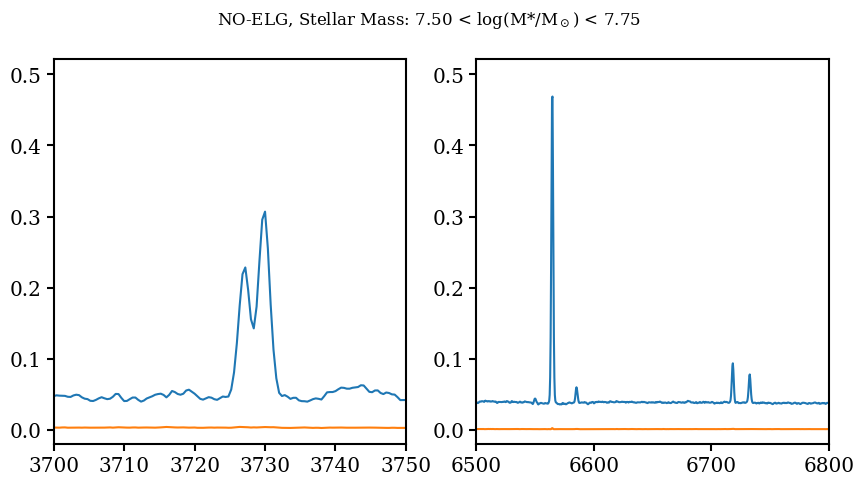

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_noelg_7.50_7.75.fits
(51, 8000) (8000,)
Saved NO-ELG mstar bin [7.50, 7.75]: 1 mean + 50 bootstraps


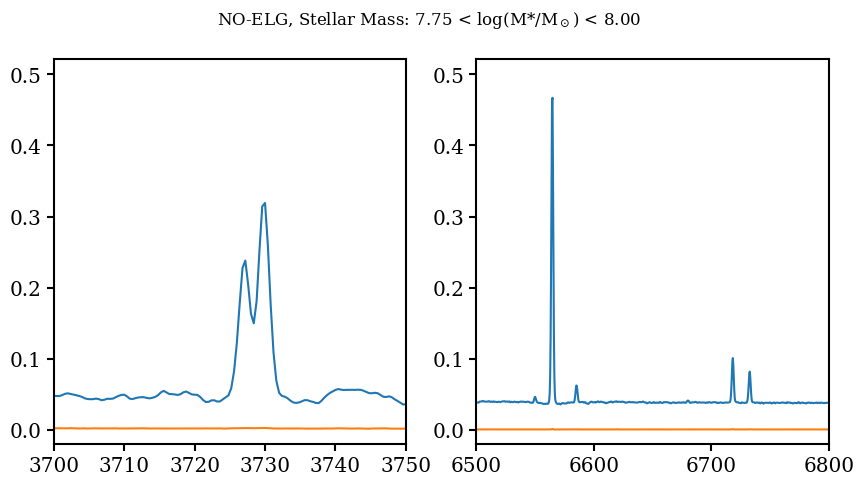

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_noelg_7.75_8.00.fits
(51, 8000) (8000,)
Saved NO-ELG mstar bin [7.75, 8.00]: 1 mean + 50 bootstraps


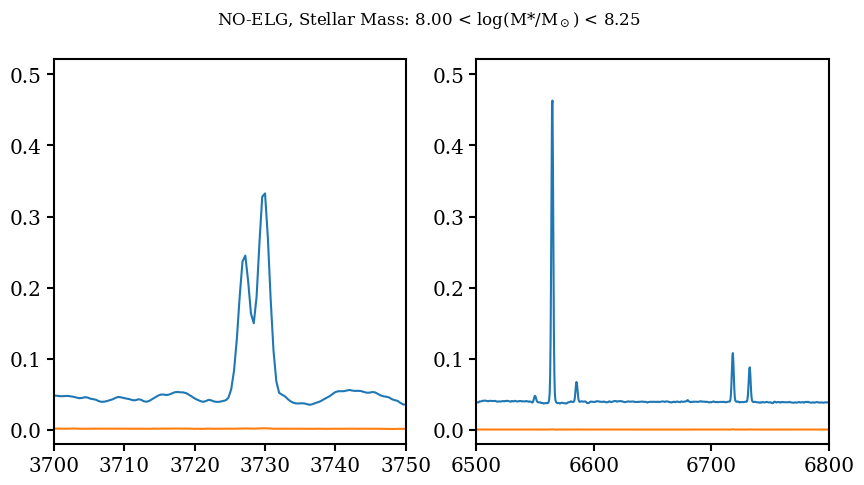

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_noelg_8.00_8.25.fits
(51, 8000) (8000,)
Saved NO-ELG mstar bin [8.00, 8.25]: 1 mean + 50 bootstraps


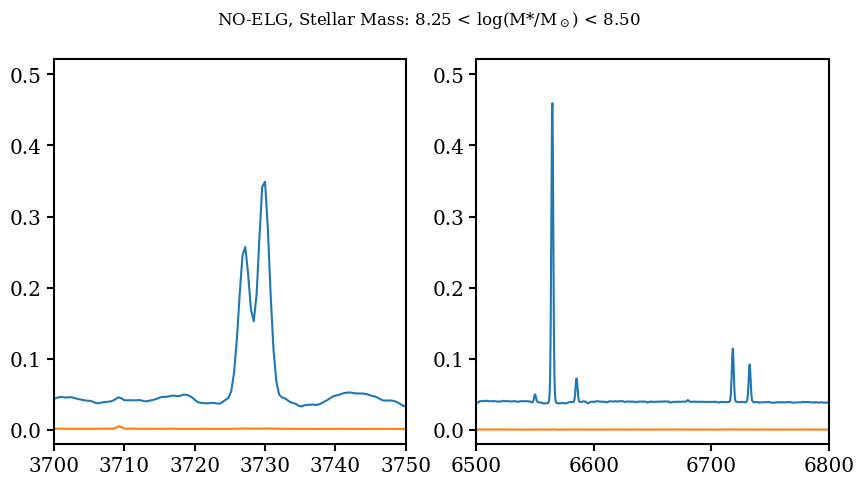

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_noelg_8.25_8.50.fits
(51, 8000) (8000,)
Saved NO-ELG mstar bin [8.25, 8.50]: 1 mean + 50 bootstraps


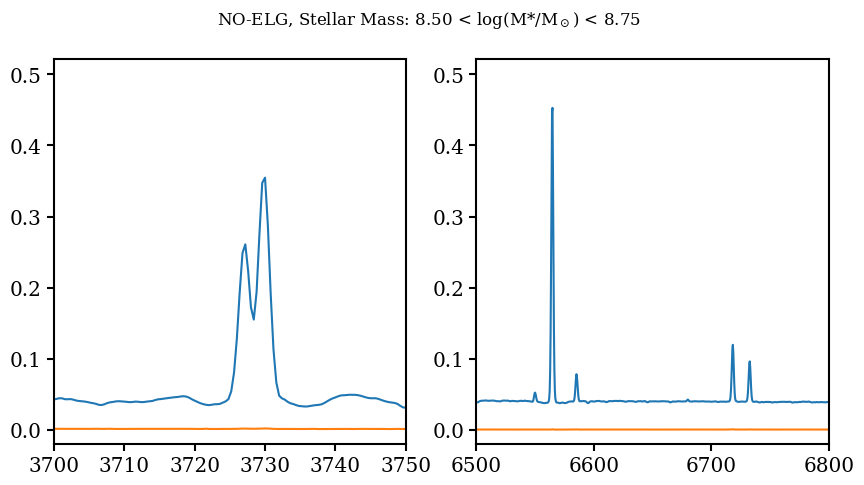

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_noelg_8.50_8.75.fits
(51, 8000) (8000,)
Saved NO-ELG mstar bin [8.50, 8.75]: 1 mean + 50 bootstraps


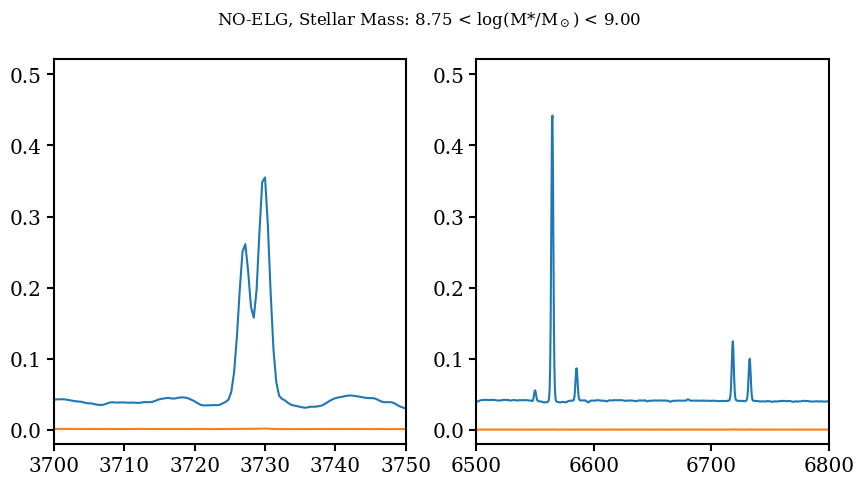

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_noelg_8.75_9.00.fits
(51, 8000) (8000,)
Saved NO-ELG mstar bin [8.75, 9.00]: 1 mean + 50 bootstraps


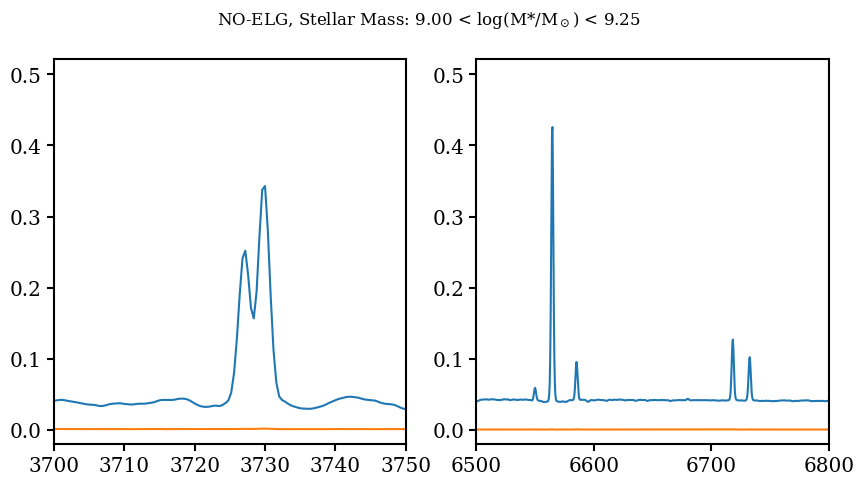

Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_noelg_9.00_9.25.fits
(51, 8000) (8000,)
Saved NO-ELG mstar bin [9.00, 9.25]: 1 mean + 50 bootstraps


In [144]:
from elg_explore import write_stacked_spectra

stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/"
n_boot_save = 50  # number of bootstrap realizations to save

# --- ELG stacks ---
elg_indices = [i for i in stack_spec_elg_mstar_dict if not np.all(np.isnan(stack_spec_elg_mstar_dict[i]))]
n_elg = len(elg_indices)

if n_elg > 0:
    n_wave = len(wave)

    for j, i in enumerate(elg_indices):
        ms_min_i = mstar_bins[i]
        ms_max_i = mstar_bins[i + 1]

        with open(stack_path + f"stacks_spec_elg_mstar_{ms_min_i:.2f}_{ms_max_i:.2f}.pkl", 'rb') as f:
            saved = pickle.load(f)

        flux_mean = saved['stack_spec']
        err_mean = saved['stack_err']
        all_stacks = saved['all_stacks']  # (n_bootstrap, n_wave)

        ivar_mean = np.where(err_mean > 0, 1.0 / err_mean**2, 0.0)

         # Plot stacked spectra
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle(f"ELG, Stellar Mass: {ms_min_i:.2f} < log(M*/M$_\\odot$) < {ms_max_i:.2f}")
        ax[0].plot(wave, flux_mean, label="ELG")
        ax[1].plot(wave, flux_mean, label="ELG")

        ax[0].plot(wave, err_mean, label="ERR")
        ax[1].plot(wave, err_mean, label="ERR")

        ax[0].set_xlim([3700, 3750])
        ax[1].set_xlim([6500, 6800])        
        try:
            for axi in ax:
                axi.set_ylim([-0.02, np.nanmax(stack_spec_elg) * 1.1])
        except:
            pass
        plt.show()

        # Select n_boot_save random bootstrap realizations
        rng = np.random.default_rng(42)
        boot_idx = rng.choice(len(all_stacks), size=min(n_boot_save, len(all_stacks)), replace=False)
        boot_stacks = all_stacks[boot_idx]

        # Row 0 = mean stack, rows 1-N = bootstrap realizations
        n_rows = 1 + len(boot_idx)
        all_flux = np.zeros((n_rows, n_wave))
        all_ivar = np.zeros((n_rows, n_wave))

        # Mean stack
        all_flux[0] = np.where(np.isfinite(flux_mean), flux_mean, 0.0)
        all_ivar[0] = np.where(np.isfinite(ivar_mean) & (all_flux[0] != 0), ivar_mean, 0.0)

        # Bootstrap realizations (use same ivar as mean stack — they share the same noise properties)
        for k in range(len(boot_idx)):
            boot_flux_k = boot_stacks[k]
            all_flux[k + 1] = np.where(np.isfinite(boot_flux_k), boot_flux_k, 0.0)
            all_ivar[k + 1] = all_ivar[0]  # same noise estimate

        # stackid 0 = mean, stackids 1+ = bootstrap
        stackids = np.arange(n_rows)

        write_stacked_spectra(
            outfile=stack_path + f"stack_mstar_elg_{ms_min_i:.2f}_{ms_max_i:.2f}.fits",
            wave=wave[wave < 6800],
            flux=all_flux[:,wave < 6800],
            ivar=all_ivar[:,wave < 6800],
            stackids=stackids,
            stack_redshift=np.zeros(n_rows),
            table_column_dict={
                'IS_MEAN': np.array([1] + [0] * len(boot_idx)),
                'NOBJ': np.full(n_rows, saved['n_galaxies']),
            },
            table_format_dict={
                'IS_MEAN': 'K',
                'NOBJ': 'K',
            },
        )

        print(all_flux[:,wave < 6800].shape,wave[wave < 6800].shape )
        print(f"Saved ELG mstar bin [{ms_min_i:.2f}, {ms_max_i:.2f}]: 1 mean + {len(boot_idx)} bootstraps")

# --- NO-ELG stacks ---
noelg_indices = [i for i in stack_spec_noelg_mstar_dict if not np.all(np.isnan(stack_spec_noelg_mstar_dict[i]))]
n_noelg = len(noelg_indices)

if n_noelg > 0:
    n_wave = len(wave)

    for j, i in enumerate(noelg_indices):
        ms_min_i = mstar_bins[i]
        ms_max_i = mstar_bins[i + 1]

        with open(stack_path + f"stacks_spec_noelg_mstar_{ms_min_i:.2f}_{ms_max_i:.2f}.pkl", 'rb') as f:
            saved = pickle.load(f)

        flux_mean = saved['stack_spec']
        err_mean = saved['stack_err']
        all_stacks = saved['all_stacks']

        ivar_mean = np.where(err_mean > 0, 1.0 / err_mean**2, 0.0)

         # Plot stacked spectra
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle(f"NO-ELG, Stellar Mass: {ms_min_i:.2f} < log(M*/M$_\\odot$) < {ms_max_i:.2f}")
        ax[0].plot(wave, flux_mean, label="ELG")
        ax[1].plot(wave, flux_mean, label="ELG")

        ax[0].plot(wave, err_mean, label="ERR")
        ax[1].plot(wave, err_mean, label="ERR")

        ax[0].set_xlim([3700, 3750])
        ax[1].set_xlim([6500, 6800])        
        try:
            for axi in ax:
                axi.set_ylim([-0.02, np.nanmax(stack_spec_elg) * 1.1])
        except:
            pass
        plt.show()

        rng = np.random.default_rng(42)
        boot_idx = rng.choice(len(all_stacks), size=min(n_boot_save, len(all_stacks)), replace=False)
        boot_stacks = all_stacks[boot_idx]

        n_rows = 1 + len(boot_idx)
        all_flux = np.zeros((n_rows, n_wave))
        all_ivar = np.zeros((n_rows, n_wave))

        all_flux[0] = np.where(np.isfinite(flux_mean), flux_mean, 0.0)
        all_ivar[0] = np.where(np.isfinite(ivar_mean) & (all_flux[0] != 0), ivar_mean, 0.0)

        for k in range(len(boot_idx)):
            boot_flux_k = boot_stacks[k]
            all_flux[k + 1] = np.where(np.isfinite(boot_flux_k), boot_flux_k, 0.0)
            all_ivar[k + 1] = all_ivar[0]

        stackids = np.arange(n_rows)

        write_stacked_spectra(
            outfile=stack_path + f"stack_mstar_noelg_{ms_min_i:.2f}_{ms_max_i:.2f}.fits",
            wave=wave[wave < 6800],
            flux=all_flux[:,wave < 6800],
            ivar=all_ivar[:,wave < 6800],
            stackids=stackids,
            stack_redshift=np.zeros(n_rows),
            table_column_dict={
                'IS_MEAN': np.array([1] + [0] * len(boot_idx)),
                'NOBJ': np.full(n_rows, saved['n_galaxies']),
            },
            table_format_dict={
                'IS_MEAN': 'K',
                'NOBJ': 'K',
            },
        )
        print(all_flux[:,wave < 6800].shape,wave[wave < 6800].shape )
        
        print(f"Saved NO-ELG mstar bin [{ms_min_i:.2f}, {ms_max_i:.2f}]: 1 mean + {len(boot_idx)} bootstraps")
        

In [147]:
fits.open(f"{stack_path}/stack_mstar_noelg_7.75_8.00.fits")[2].data.shape

(51, 8000)

#Running fastspecfit on the stacks

- stackfit stack_mstar_bins_noelg.fits -o fastspec_stack_mstar_bins_noelg.fits --mp 16
- stackfit stack_mstar_bins_elg.fits -o fastspec_stack_mstar_bins_elg.fits --mp 16

In [6]:
mstar_bins

array([6.  , 6.25, 6.5 , 6.75, 7.  , 7.25, 7.5 , 7.75, 8.  , 8.25, 8.5 ,
       8.75, 9.  , 9.25])

The take away from the bottom plot is to use boxflux !!

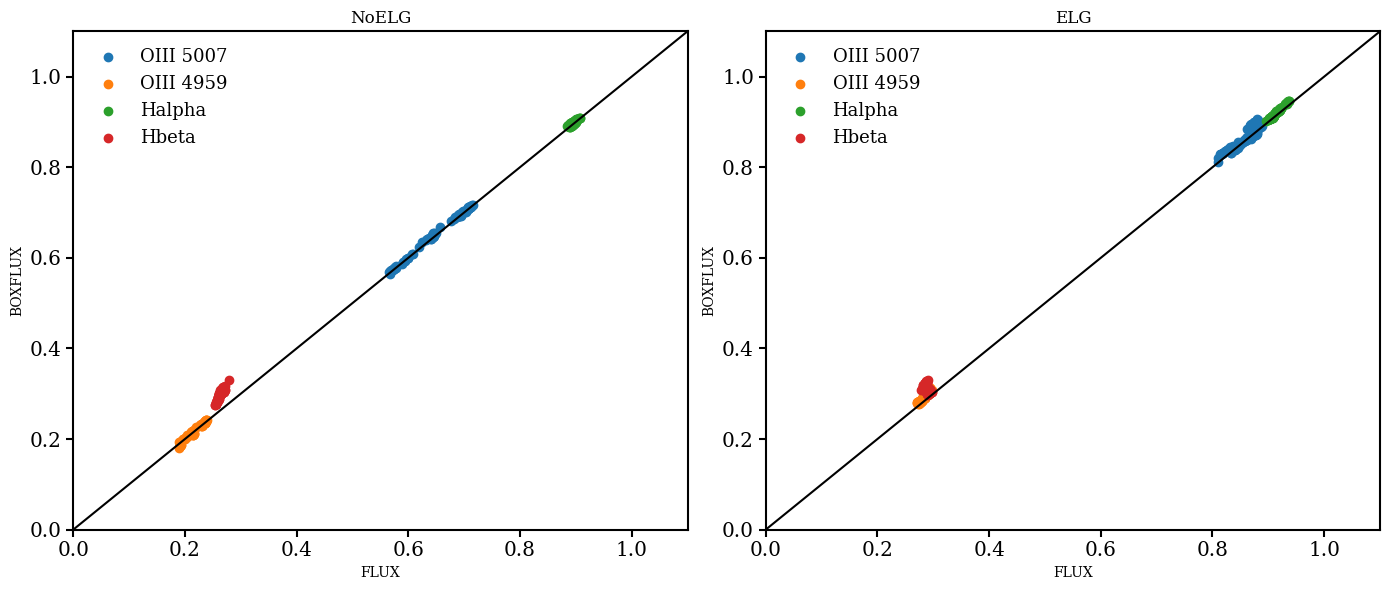

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

all_elg_data = []
all_noelg_data = []

# Collect mean row (row 0) from each bin
for i in range(len(mstar_bins) - 1):
    ms_min_i = mstar_bins[i]
    ms_max_i = mstar_bins[i + 1]

    elg_file = f"{stack_path}/fastspec_stack_mstar_elg_{ms_min_i:.2f}_{ms_max_i:.2f}.fits"
    noelg_file = f"{stack_path}/fastspec_stack_mstar_noelg_{ms_min_i:.2f}_{ms_max_i:.2f}.fits"

    if os.path.exists(elg_file):
        try:
            t = Table.read(elg_file, hdu=3)
            for i in range(10):
                all_elg_data.append(t[i])  # row 0 = mean stack
        except:
            pass

    if os.path.exists(noelg_file):
        try:
            t = Table.read(noelg_file, hdu=3)
            for i in range(10):
                all_noelg_data.append(t[i])
        except:
            pass

# Plot FLUX vs BOXFLUX
for ax, data_list, title in zip(axes, [all_noelg_data, all_elg_data], ["NoELG", "ELG"]):
    oiii_5007_flux = np.array([d["OIII_5007_FLUX"] for d in data_list])
    oiii_5007_box = np.array([d["OIII_5007_BOXFLUX"] for d in data_list])
    oiii_4959_flux = np.array([d["OIII_4959_FLUX"] for d in data_list])
    oiii_4959_box = np.array([d["OIII_4959_BOXFLUX"] for d in data_list])
    ha_flux = np.array([d["HALPHA_FLUX"] for d in data_list])
    ha_box = np.array([d["HALPHA_BOXFLUX"] for d in data_list])
    hb_flux = np.array([d["HBETA_FLUX"] for d in data_list])
    hb_box = np.array([d["HBETA_BOXFLUX"] for d in data_list])

    ax.scatter(oiii_5007_flux, oiii_5007_box, label="OIII 5007")
    ax.scatter(oiii_4959_flux, oiii_4959_box, label="OIII 4959")
    ax.scatter(ha_flux, ha_box, label="Halpha")
    ax.scatter(hb_flux, hb_box, label="Hbeta")
    ax.plot([0., 1.1], [0., 1.1], color="k")
    ax.set_xlim([0, 1.1])
    ax.set_ylim([0, 1.1])
    ax.set_xlabel("FLUX")
    ax.set_ylabel("BOXFLUX")
    ax.set_title(title)
    ax.legend(fontsize=13)

plt.tight_layout()
plt.show()


/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_6.75_7.00.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_7.00_7.25.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_7.25_7.50.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_7.50_7.75.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_7.75_8.00.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_8.00_8.25.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_8.25_8.50.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_8.50_8.75.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack

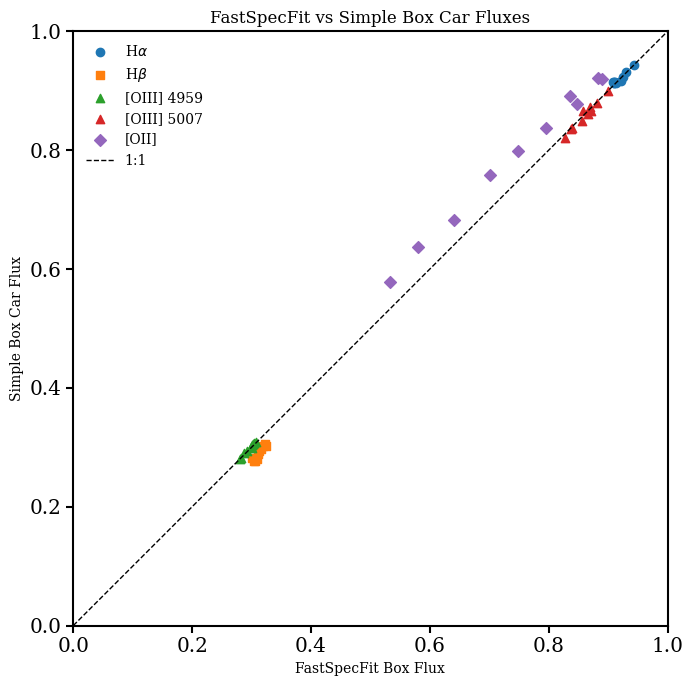

In [150]:
##we compare the fastspec fluxes with our simple box car fluxes
halpha_simple = []
halpha_fspec = []

hbeta_simple = []
hbeta_fspec = []

oiii_1_simple = []
oiii_2_simple = []

oiii_1_fspec = []
oiii_2_fspec = []

oii_simple = []
oii_fspec = []

for i in range(len(mstar_bins)-1):
    ms_min_i = mstar_bins[i]
    ms_max_i = mstar_bins[i + 1]
    fspec_file = f"{stack_path}/fastspec_stack_mstar_elg_{ms_min_i:.2f}_{ms_max_i:.2f}.fits"
    
    if os.path.exists(fspec_file):
        print(fspec_file)
        
        temp = measure_all_lines_boxcar(wave, stack_spec_elg_mstar_dict[i], LINE_WINDOWS)

        halpha_simple.append(temp["Halpha_flux"])
        hbeta_simple.append(temp["Hbeta_flux"])
        oiii_1_simple.append(temp["OIII_5007_flux"])
        oiii_2_simple.append(temp["OIII_4959_flux"])
        
        oii_simple.append(temp["OII_flux"])

        t = Table.read(fspec_file, hdu=3)

        boxstr = "BOX"
        halpha_fspec.append(t[f"HALPHA_{boxstr}FLUX"][0])
        hbeta_fspec.append(t[f"HBETA_{boxstr}FLUX"][0])
        oiii_1_fspec.append(t[f"OIII_5007_{boxstr}FLUX"][0])
        oiii_2_fspec.append(t[f"OIII_4959_{boxstr}FLUX"][0])
        
        oii_fspec.append(t["OII_3726_FLUX"][0] + t["OII_3729_FLUX"][0])
        # oii_fspec.append(t["OII_3729_BOXFLUX"][0] + t["OII_3726_BOXFLUX"][0])
        
    
    else:
        pass


fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(halpha_fspec, halpha_simple, marker = 'o', label=r'H$\alpha$')
ax.scatter(hbeta_fspec, hbeta_simple,marker =  's', label=r'H$\beta$')
ax.scatter(oiii_2_fspec, oiii_2_simple, marker = '^', label='[OIII] 4959')
ax.scatter(oiii_1_fspec, oiii_1_simple, marker = '^', label='[OIII] 5007')

ax.scatter(oii_fspec, oii_simple, marker = 'D', label='[OII]')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='1:1')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('FastSpecFit Box Flux')
ax.set_ylabel('Simple Box Car Flux')
ax.set_title('FastSpecFit vs Simple Box Car Fluxes')
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


In [151]:
##we compare the fastspec fluxes with our simple box car fluxes
# ELG
halpha_simple_elg = []
halpha_fspec_elg = []
hbeta_simple_elg = []
hbeta_fspec_elg = []
oiii_1_simple_elg = []
oiii_2_simple_elg = []
oiii_1_fspec_elg = []
oiii_2_fspec_elg = []
oii_simple_elg = []
oii_fspec_elg = []

# No ELG
halpha_simple_noelg = []
halpha_fspec_noelg = []
hbeta_simple_noelg = []
hbeta_fspec_noelg = []
oiii_1_simple_noelg = []
oiii_2_simple_noelg = []
oiii_1_fspec_noelg = []
oiii_2_fspec_noelg = []
oii_simple_noelg = []
oii_fspec_noelg = []

for i in range(len(mstar_bins)-1):
    ms_min_i = mstar_bins[i]
    ms_max_i = mstar_bins[i + 1]
    
    for label, simple_dict, lists in [
        ("elg", stack_spec_elg_mstar_dict, 
         (halpha_simple_elg, halpha_fspec_elg, hbeta_simple_elg, hbeta_fspec_elg,
          oiii_1_simple_elg, oiii_1_fspec_elg, oiii_2_simple_elg, oiii_2_fspec_elg,
          oii_simple_elg, oii_fspec_elg)),
        ("noelg", stack_spec_noelg_mstar_dict,
         (halpha_simple_noelg, halpha_fspec_noelg, hbeta_simple_noelg, hbeta_fspec_noelg,
          oiii_1_simple_noelg, oiii_1_fspec_noelg, oiii_2_simple_noelg, oiii_2_fspec_noelg,
          oii_simple_noelg, oii_fspec_noelg)),
    ]:
        fspec_file = f"{stack_path}/fastspec_stack_mstar_{label}_{ms_min_i:.2f}_{ms_max_i:.2f}.fits"
        
        if os.path.exists(fspec_file):
            print(fspec_file)
            
            temp = measure_all_lines_boxcar(wave, simple_dict[i], LINE_WINDOWS)
            lists[0].append(temp["Halpha_flux"])
            lists[2].append(temp["Hbeta_flux"])
            lists[4].append(temp["OIII_5007_flux"])
            lists[6].append(temp["OIII_4959_flux"])
            lists[8].append(temp["OII_flux"])
            
            t = Table.read(fspec_file, hdu=3)
            boxstr = "BOX"
            lists[1].append(t[f"HALPHA_{boxstr}FLUX"][0])
            lists[3].append(t[f"HBETA_{boxstr}FLUX"][0])
            lists[5].append(t[f"OIII_5007_{boxstr}FLUX"][0])
            lists[7].append(t[f"OIII_4959_{boxstr}FLUX"][0])
            lists[9].append(t["OII_3726_FLUX"][0] + t["OII_3729_FLUX"][0])



/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_6.75_7.00.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_7.00_7.25.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_7.25_7.50.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_noelg_7.25_7.50.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_7.50_7.75.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_noelg_7.50_7.75.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_elg_7.75_8.00.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec_stack_mstar_noelg_7.75_8.00.fits
/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar//fastspec

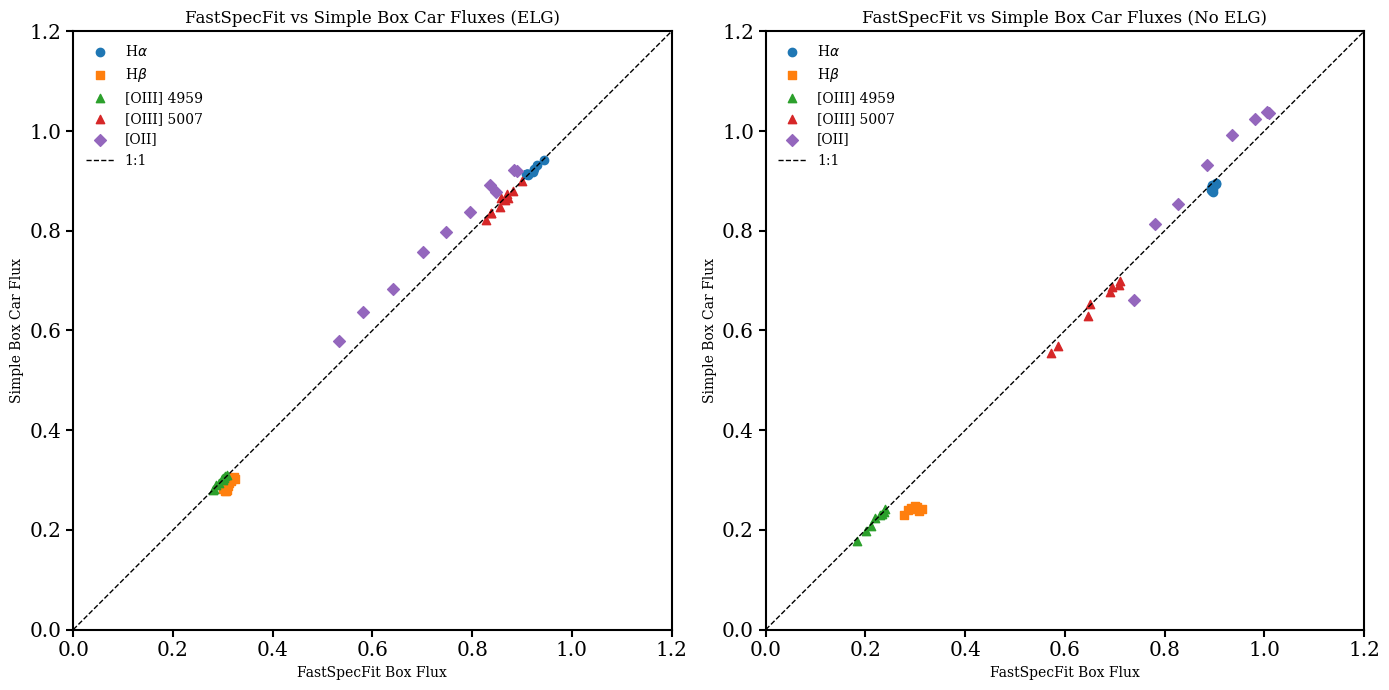

In [152]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, title, ha_s, ha_f, hb_s, hb_f, o1_s, o1_f, o2_s, o2_f, oii_s, oii_f in [
    (axes[0], "ELG",
     halpha_simple_elg, halpha_fspec_elg, hbeta_simple_elg, hbeta_fspec_elg,
     oiii_1_simple_elg, oiii_1_fspec_elg, oiii_2_simple_elg, oiii_2_fspec_elg,
     oii_simple_elg, oii_fspec_elg),
    (axes[1], "No ELG",
     halpha_simple_noelg, halpha_fspec_noelg, hbeta_simple_noelg, hbeta_fspec_noelg,
     oiii_1_simple_noelg, oiii_1_fspec_noelg, oiii_2_simple_noelg, oiii_2_fspec_noelg,
     oii_simple_noelg, oii_fspec_noelg),
]:
    ax.scatter(ha_f, ha_s, marker='o', label=r'H$\alpha$')
    ax.scatter(hb_f, hb_s, marker='s', label=r'H$\beta$')
    ax.scatter(o2_f, o2_s, marker='^', label='[OIII] 4959')
    ax.scatter(o1_f, o1_s, marker='^', label='[OIII] 5007')
    ax.scatter(oii_f, oii_s, marker='D', label='[OII]')
    ax.plot([0, 2], [0, 2], 'k--', lw=1, label='1:1')
    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    ax.set_xlabel('FastSpecFit Box Flux')
    ax.set_ylabel('Simple Box Car Flux')
    ax.set_title(f'FastSpecFit vs Simple Box Car Fluxes ({title})')
    ax.legend()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [3]:
# Helper: flux error from ivar
def flux_err(ivar):
    return np.where(ivar > 0, 1.0 / np.sqrt(ivar), np.nan)

# Helper: sum error from two ivars
def sum_err_from_ivar(ivar1, ivar2):
    return np.sqrt(1.0 / ivar1 + 1.0 / ivar2)

# Helper: ratio error via propagation  d(a/b) = (a/b) * sqrt((da/a)^2 + (db/b)^2)
def ratio_err(a, a_err, b, b_err):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = a / b
        err = np.abs(ratio) * np.sqrt((a_err / a)**2 + (b_err / b)**2)
    return ratio, err

# Helper: log10 ratio error  d(log10(r)) = dr / (r * ln(10))
def log_ratio_err(a, a_err, b, b_err):
    ratio, r_err = ratio_err(a, a_err, b, b_err)
    with np.errstate(divide='ignore', invalid='ignore'):
        log_val = np.where(ratio > 0, np.log10(ratio), np.nan)
        log_err = np.where(ratio > 0, r_err / (ratio * np.log(10)), np.nan)
    return log_val, log_err


In [4]:
from metallicity import get_metallicity_S22

In [5]:
from astropy.table import Table

stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar"

def compute_quantities_from_row(t):
    """Compute all derived quantities from a single FastSpecFit row."""
    ha = t["HALPHA_BOXFLUX"]
    hb = t["HBETA_BOXFLUX"]
    ha_ew = t["HALPHA_EW"]
    oiii_5007 = t["OIII_5007_BOXFLUX"]
    oiii_4959 = t["OIII_4959_BOXFLUX"]
    oiii_total = oiii_5007 + oiii_4959
    oii_total = t["OII_3726_FLUX"] + t["OII_3729_FLUX"]
    sii_total = t["SII_6716_BOXFLUX"] + t["SII_6731_BOXFLUX"]
    with np.errstate(divide='ignore', invalid='ignore'):
        ha_hb = ha / hb
        oiii_oii = oiii_total / oii_total
        log_oiii_oii = np.log10(oiii_oii) if oiii_oii > 0 else np.nan
        oiii_hb = oiii_total / hb
        log_oiii_hb = np.log10(oiii_hb) if oiii_hb > 0 else np.nan
        sii_ha = sii_total / ha
        log_sii_ha = np.log10(sii_ha) if sii_ha > 0 else np.nan
        r23 = (oiii_total + oii_total) / hb
        log_r23 = np.log10(r23) if r23 > 0 else np.nan
    return {
        "halpha_ew": ha_ew,
        "ha_hb": ha_hb,
        "log_oiii_oii": log_oiii_oii,
        "log_oiii_hb": log_oiii_hb,
        "log_sii_halpha": log_sii_ha,
        "log_R23": log_r23,
    }

n_mstar_bins = len(mstar_bins) - 1
mstar_cens = 0.5 * (mstar_bins[:-1] + mstar_bins[1:])

quantities = ["halpha_ew", "ha_hb", "log_oiii_oii", "log_oiii_hb",
              "log_sii_halpha", "log_R23"]
mstar_data = {}
for q in quantities:
    mstar_data[q] = {
        "elg": np.full(n_mstar_bins, np.nan),
        "elg_median": np.full(n_mstar_bins, np.nan),
        "elg_err": np.full(n_mstar_bins, np.nan),
        "elg_err_lo": np.full(n_mstar_bins, np.nan),
        "elg_err_hi": np.full(n_mstar_bins, np.nan),
        "noelg": np.full(n_mstar_bins, np.nan),
        "noelg_median": np.full(n_mstar_bins, np.nan),
        "noelg_err": np.full(n_mstar_bins, np.nan),
        "noelg_err_lo": np.full(n_mstar_bins, np.nan),
        "noelg_err_hi": np.full(n_mstar_bins, np.nan),
    }

def process_file(fspec_file, sample_key, i):
    """Read file, compute mean from row 0, bootstrap stats from rows 1+."""
    if not os.path.exists(fspec_file):
        return
    try:
        t = Table.read(fspec_file, hdu=3)
    except:
        print(f"Could not read {fspec_file}")
        return

    # Row 0 = mean stack
    mean_vals = compute_quantities_from_row(t[0])
    for q in quantities:
        mstar_data[q][sample_key][i] = mean_vals[q]

    # Rows 1+ = bootstrap realizations
    n_boot = len(t) - 1
    if n_boot > 0:
        boot_vals = {q: [] for q in quantities}
        for b in range(1, len(t)):
            bv = compute_quantities_from_row(t[b])
            for q in quantities:
                boot_vals[q].append(bv[q])

        for q in quantities:
            boot_arr = np.array(boot_vals[q])
            p16, p50, p84 = np.nanpercentile(boot_arr, [16, 50, 84])
            mstar_data[q][f"{sample_key}_median"][i] = p50
            mstar_data[q][f"{sample_key}_err"][i] = 0.5 * (p84 - p16)
            mstar_data[q][f"{sample_key}_err_lo"][i] = p50 - p16
            mstar_data[q][f"{sample_key}_err_hi"][i] = p84 - p50

# --- ELG ---

elg_zmet = []
noelg_zmet = []


for i in range(n_mstar_bins):
    ms_min_i = mstar_bins[i]
    ms_max_i = mstar_bins[i + 1]
    fspec_file = f"{stack_path}/fastspec_stack_mstar_elg_{ms_min_i:.2f}_{ms_max_i:.2f}.fits"

    try:
        temp, _ = get_metallicity_S22(Table.read(fspec_file, hdu=3) )
        elg_zmet.append( np.median(temp) )
    except:
        elg_zmet.append( np.nan)
        
        
    process_file(fspec_file, "elg", i)

print("---")

# --- NO-ELG ---
for i in range(n_mstar_bins):
    ms_min_i = mstar_bins[i]
    ms_max_i = mstar_bins[i + 1]
    fspec_file = f"{stack_path}/fastspec_stack_mstar_noelg_{ms_min_i:.2f}_{ms_max_i:.2f}.fits"

    try:
        temp, _ = get_metallicity_S22(Table.read(fspec_file, hdu=3) )
        noelg_zmet.append( np.median(temp) )
        
    except:
        noelg_zmet.append( np.nan)
        
    process_file(fspec_file, "noelg", i)

Satisyfing line snr+ratio mask = 1.0


100%|██████████| 51/51 [00:00<00:00, 491.72it/s]


Satisyfing line snr+ratio mask = 1.0


100%|██████████| 51/51 [00:00<00:00, 457.60it/s]


Satisyfing line snr+ratio mask = 1.0


...

100%|██████████| 51/51 [00:00<00:00, 590.61it/s]


Satisyfing line snr+ratio mask = 1.0


100%|██████████| 51/51 [00:00<00:00, 340.45it/s]


Satisyfing line snr+ratio mask = 1.0


100%|██████████| 51/51 [00:00<00:00, 368.22it/s]


In [6]:
mstar_cens =  0.5 * (mstar_bins[1:] + mstar_bins[:-1])

In [7]:
sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }


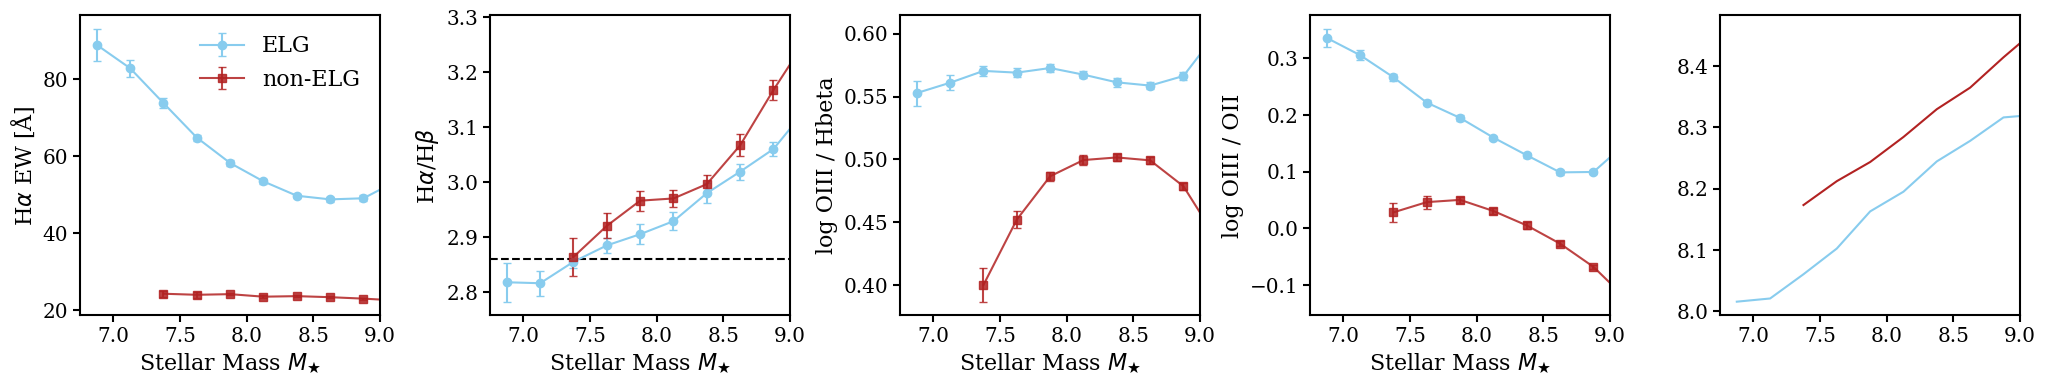

In [15]:
fig,ax = make_subplots(ncol=5,nrow=1, return_fig=True,row_spacing=0.75)

label_size =  16

#################

plot_config = [
    (ax[0], "halpha_ew", r"H$\alpha$ EW [Å]"),
    (ax[1], "ha_hb", r"H$\alpha$/H$\beta$"),
    (ax[2], "log_oiii_hb", r"log OIII / Hbeta"),
    (ax[3], "log_oiii_oii", r"log OIII / OII"),    

]

for axi, name, ylabel in plot_config:
    axi.errorbar(mstar_cens, mstar_data[name]["elg"], yerr=mstar_data[name]["elg_err"],
                 fmt='o-', capsize=3, label="ELG",color=sample_colors["ELG"])

    #this is to remove the spurious fit we have
    axi.errorbar(mstar_cens, mstar_data[name]["noelg"], yerr=mstar_data[name]["noelg_err"],
                 fmt='s-', capsize=3, label="non-ELG",color="firebrick",alpha=0.85)
    
    axi.set_ylabel(ylabel,fontsize = label_size)
    axi.set_xlabel(r"Stellar Mass $M_{\bigstar}$",fontsize = label_size)
    axi.set_xlim([6.75, 9])
    axi.set_xticks([7,7.5,8,8.5,9])


ax[4].plot(mstar_cens, elg_zmet,color=sample_colors["ELG"]  )
ax[4].plot(mstar_cens, noelg_zmet,color="firebrick"  )
ax[4].set_xlim([6.75, 9])

ax[1].axhline(2.86,color="k",ls="--")
ax[0].legend(frameon=False,fontsize = label_size)

plt.show()




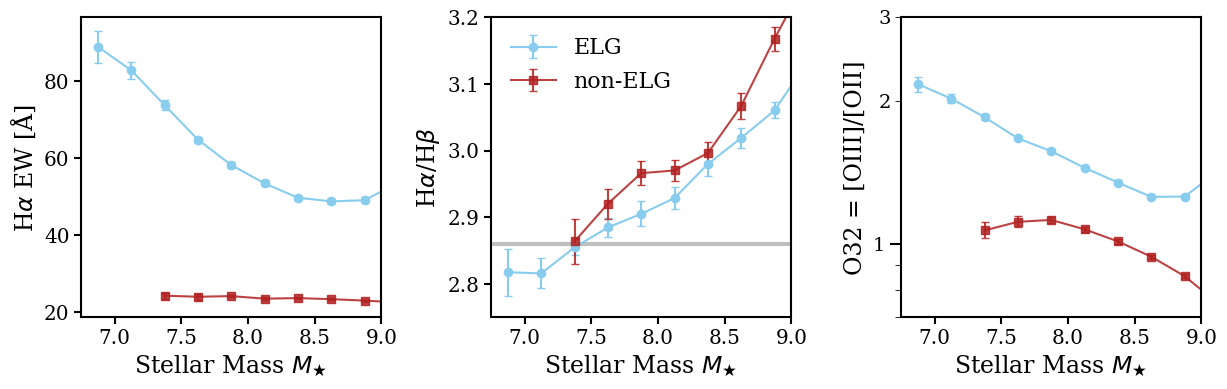

In [83]:
fig, ax = make_subplots(ncol=3, nrow=1, return_fig=True, row_spacing=0.75)
label_size = 17
plot_config = [
    (ax[0], "halpha_ew", r"H$\alpha$ EW [Å]"),
    (ax[1], "ha_hb", r"H$\alpha$/H$\beta$"),
    (ax[2], "log_oiii_oii", r"O32 = [OIII]/[OII]"),
]
for axi, name, ylabel in plot_config:
    axi.errorbar(mstar_cens, mstar_data[name]["elg"], yerr=mstar_data[name]["elg_err"],
                 fmt='o-', capsize=3, label="ELG", color=sample_colors["ELG"])

    axi.errorbar(mstar_cens, mstar_data[name]["noelg"], yerr=mstar_data[name]["noelg_err"],
                 fmt='s-', capsize=3, label="non-ELG", color="firebrick", alpha=0.85)

    axi.set_ylabel(ylabel, fontsize=label_size)
    axi.set_xlabel(r"Stellar Mass $M_{\bigstar}$", fontsize=label_size)
    axi.set_xlim([6.75, 9])
    axi.set_xticks([7, 7.5, 8, 8.5, 9])

ax[1].axhline(2.86, color="k", ls="-", alpha=0.25, lw=3, zorder=0)
ax[1].legend(frameon=False, fontsize=16)

ax[1].set_ylim([2.75,3.2])

# --- Custom log-style y-axis for ax[2] ---
major_yticks = np.array([1])
ax[2].set_yticks(np.log10(major_yticks))
ax[2].set_yticklabels([f"{int(y)}" if y >= 1 else f"{y:g}" for y in major_yticks], fontsize=14)

minor_yticks_vals = np.array([0.7, 0.8, 0.9, 2, 3])
minor_yticks = np.log10(minor_yticks_vals)
ax[2].set_yticks(minor_yticks, minor=True)
minor_labels = [""] * 3 + [f"{int(y)}" for y in [2, 3]]
ax[2].set_yticklabels(minor_labels, minor=True, fontsize=14)

ax[2].tick_params(axis='y', which='major', length=8)
ax[2].tick_params(axis='y', which='minor', length=4)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/elg_noelg_stack.pdf",bbox_inches="tight")
# 
plt.show()

/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_noelg_7.00_7.20.fits


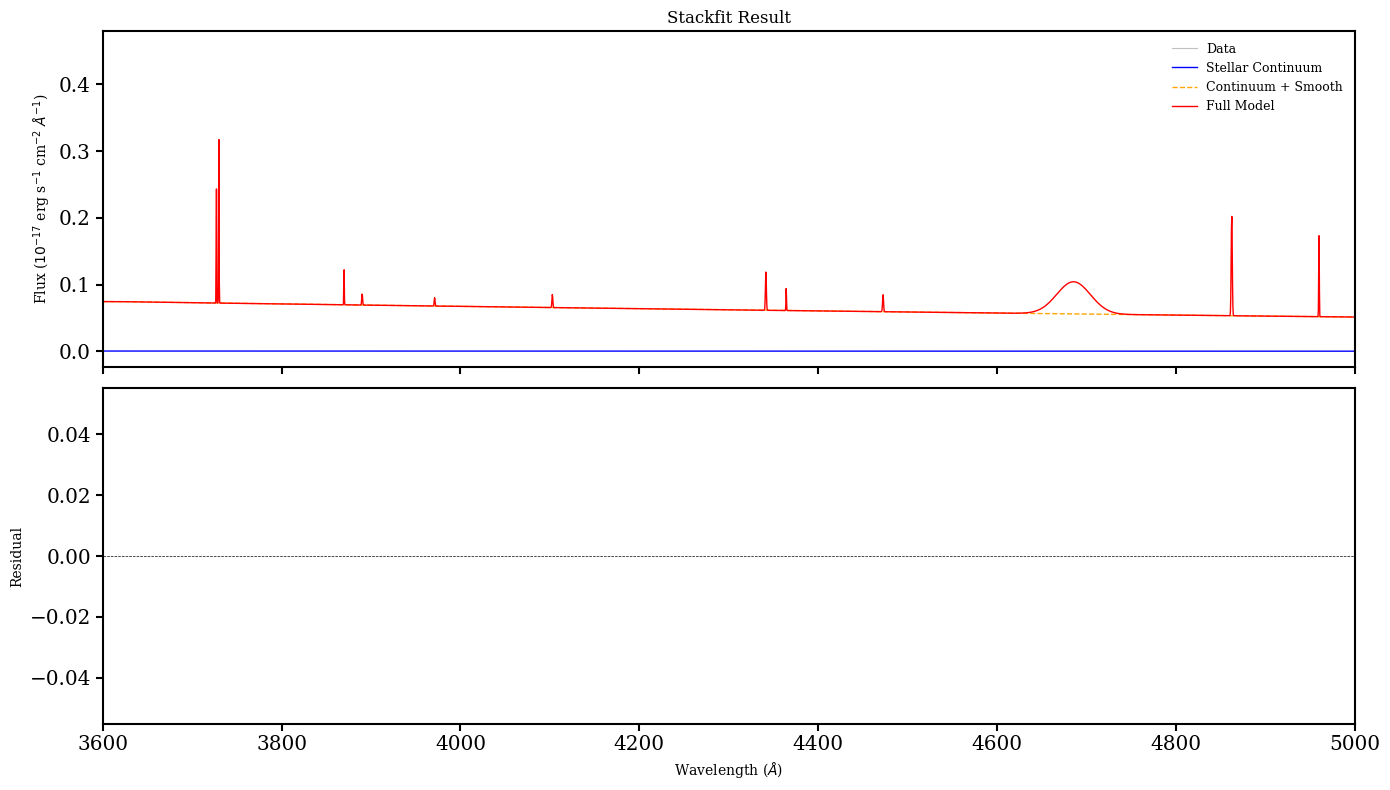

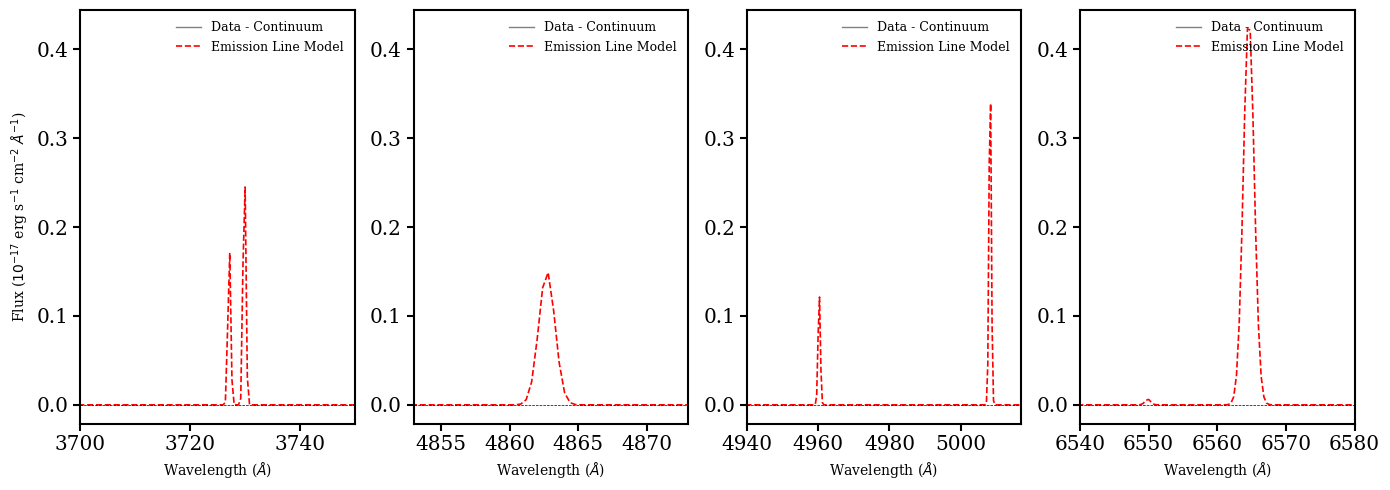

/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_noelg_7.20_7.40.fits


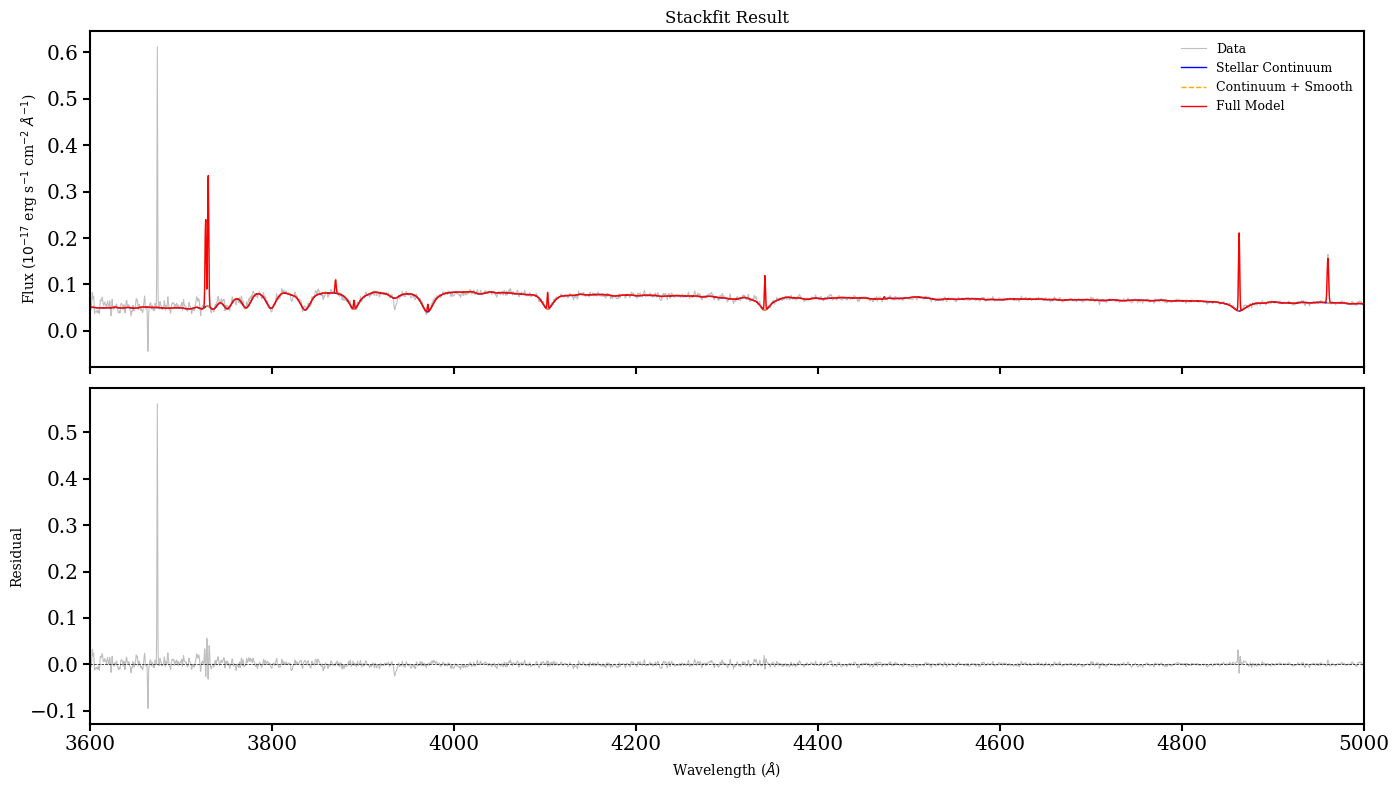

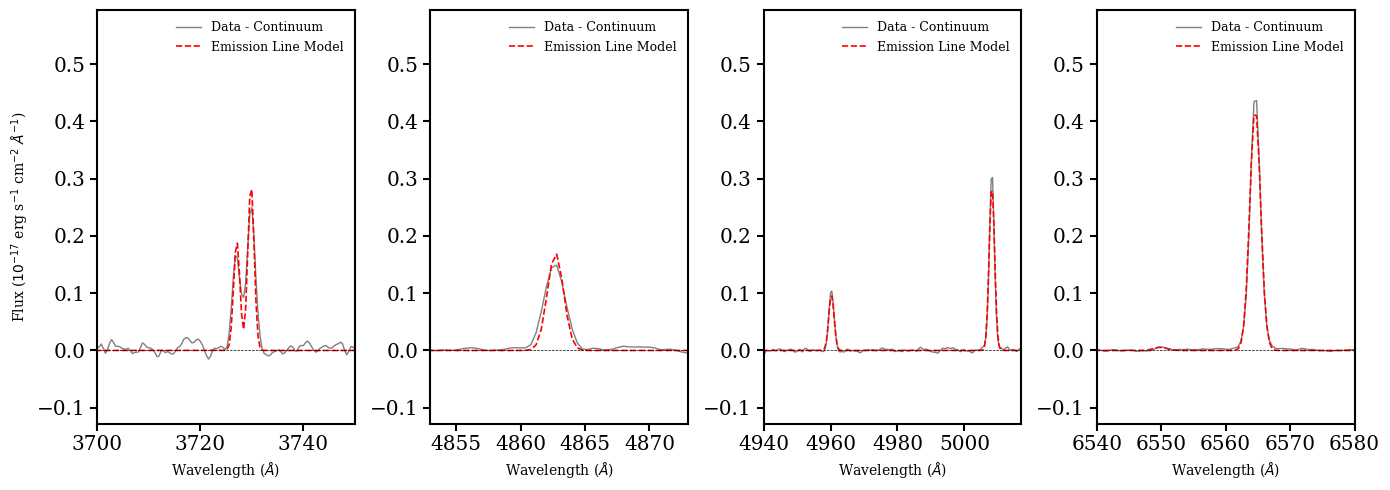

/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_noelg_7.40_7.60.fits


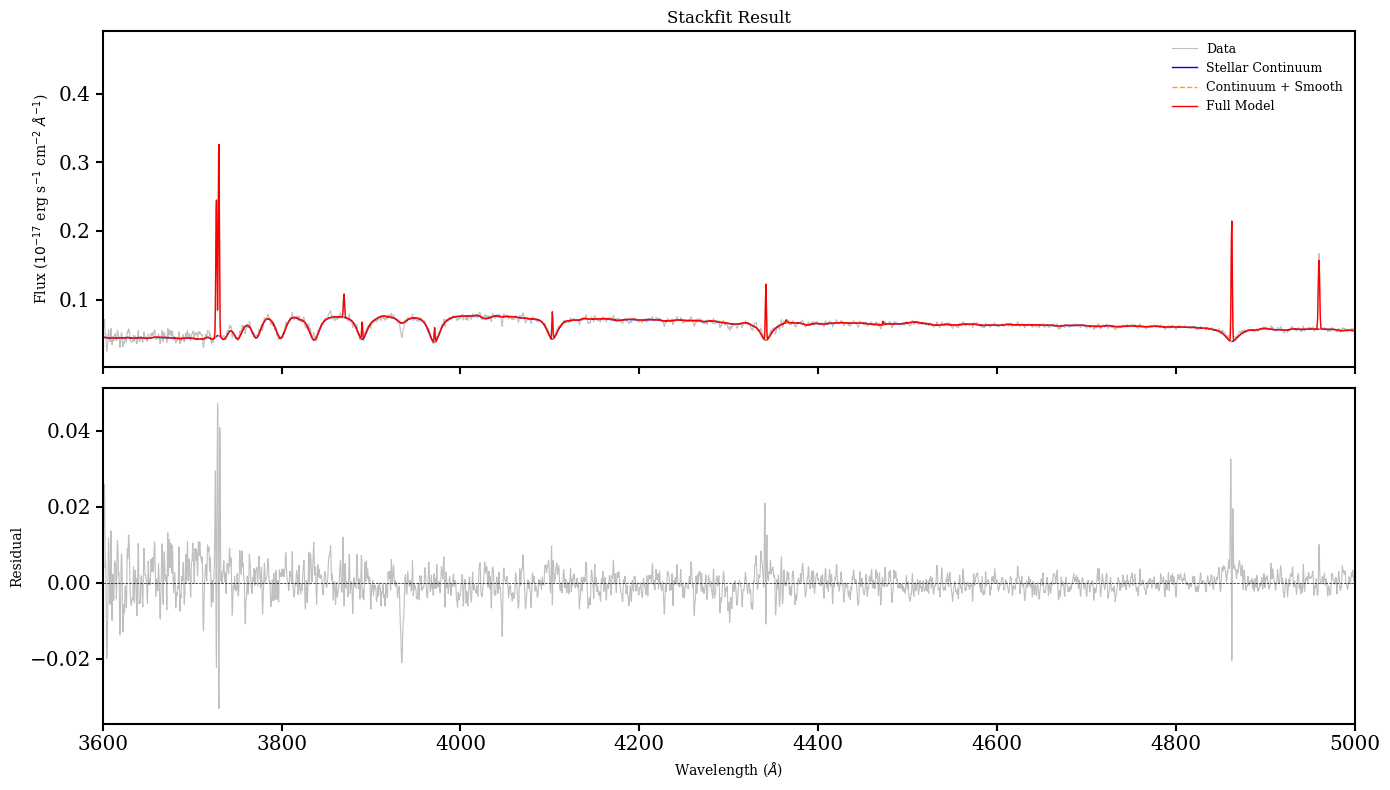

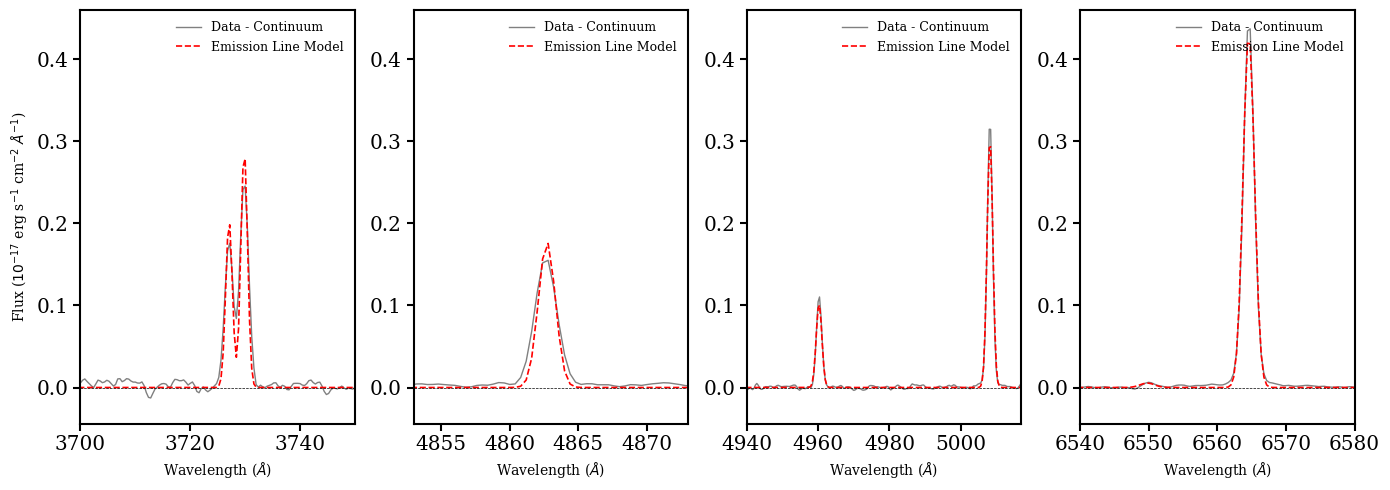

/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_noelg_7.60_7.80.fits


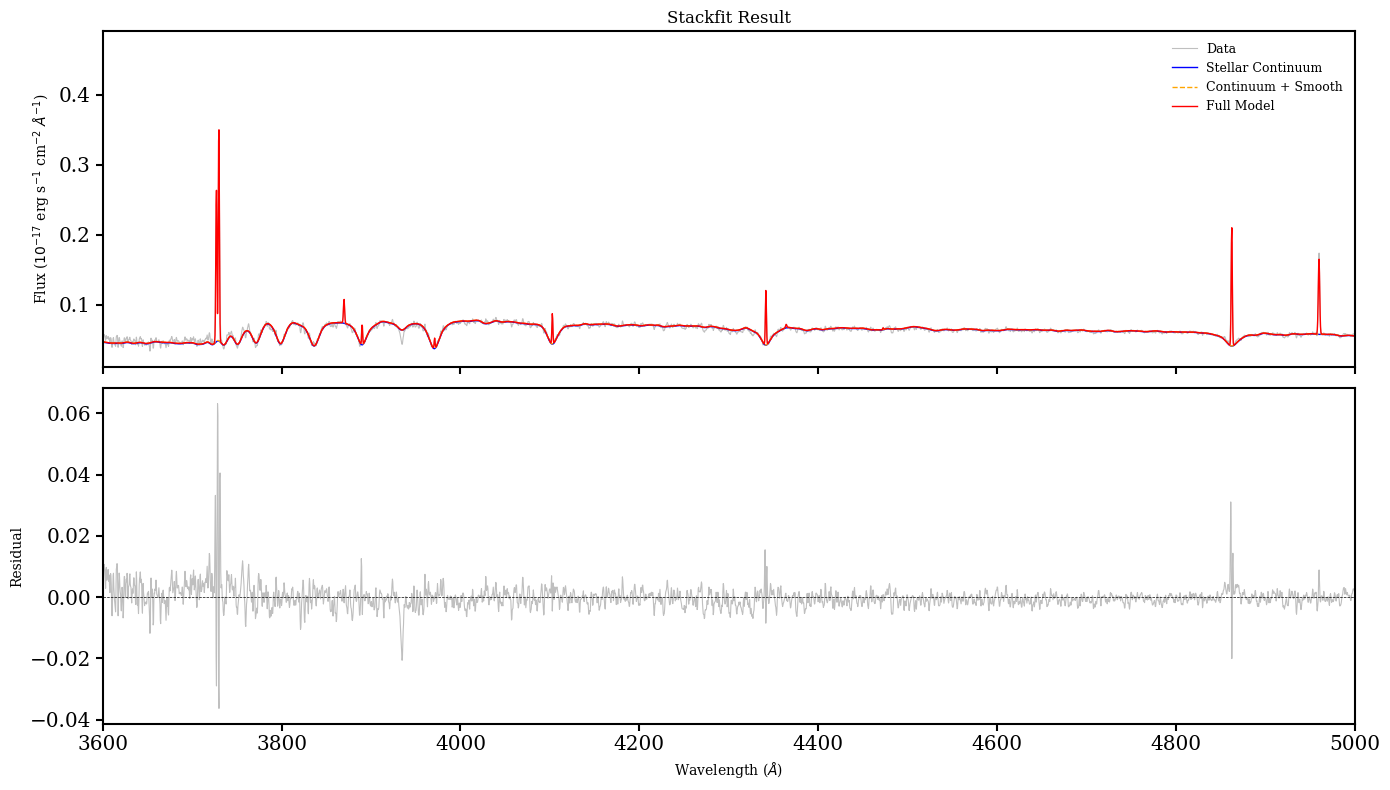

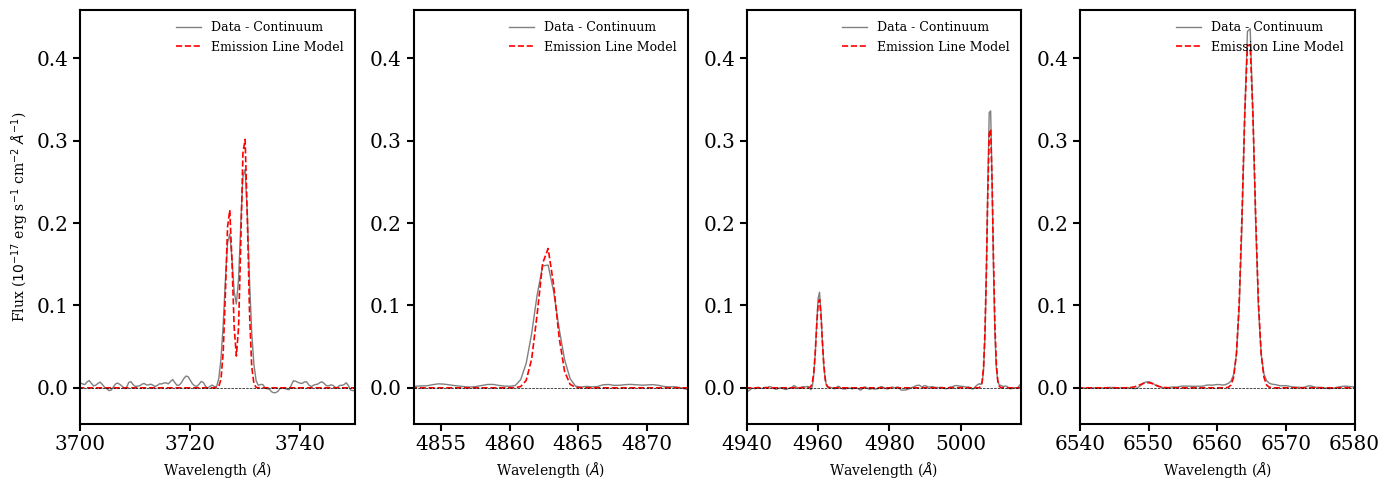

/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_noelg_7.80_8.00.fits


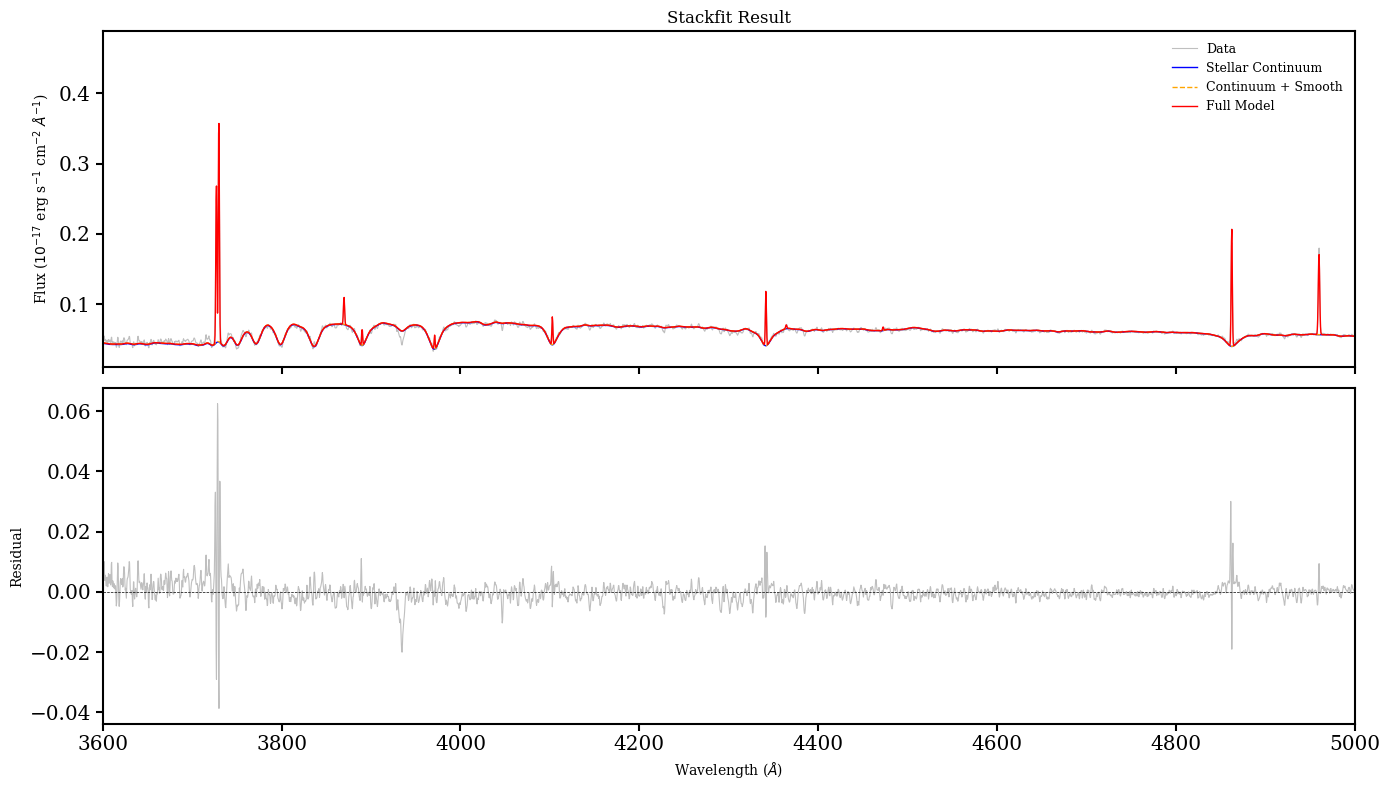

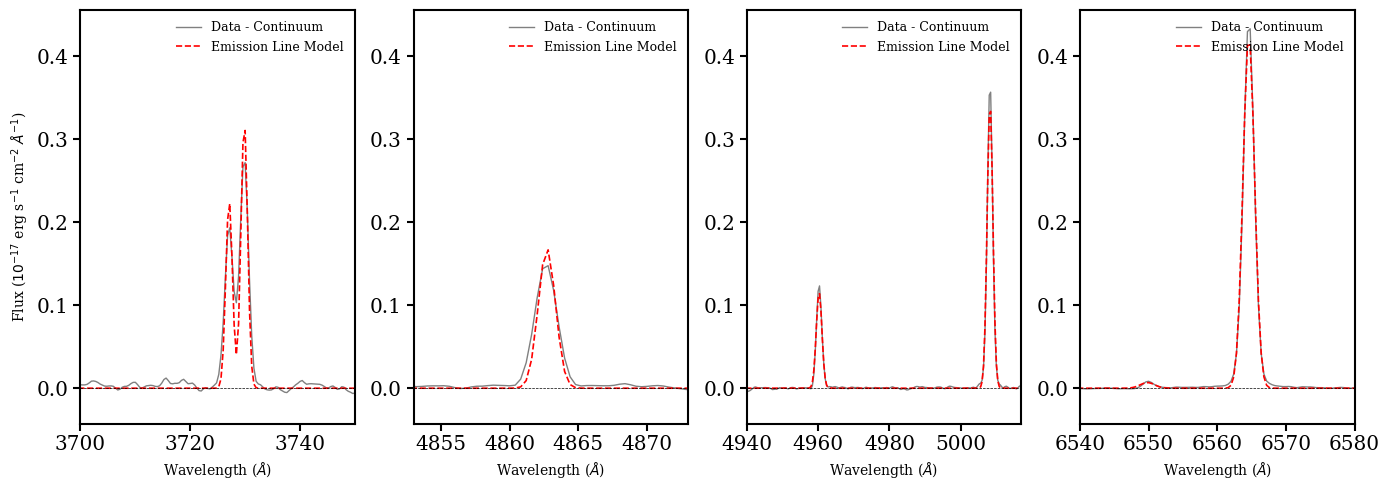

/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_noelg_8.00_8.20.fits


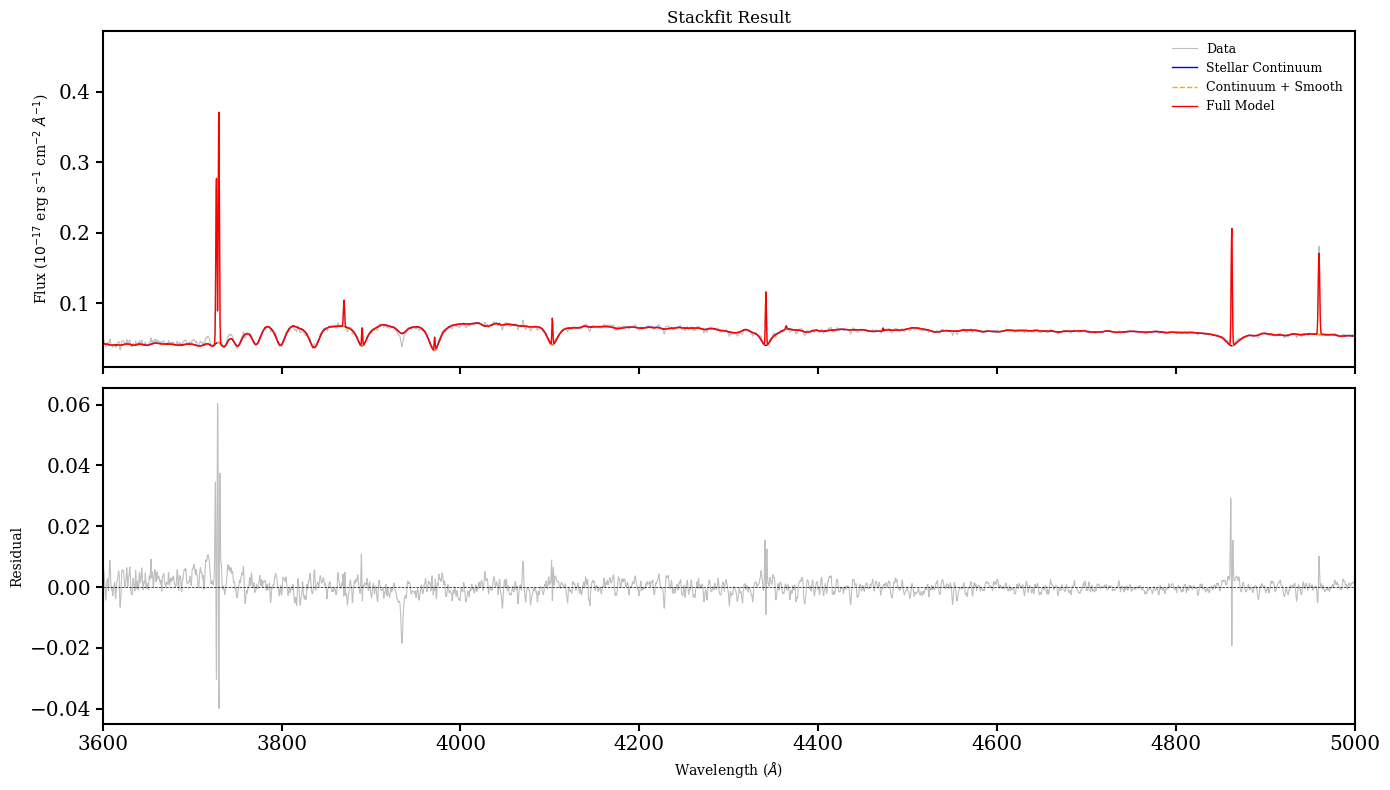

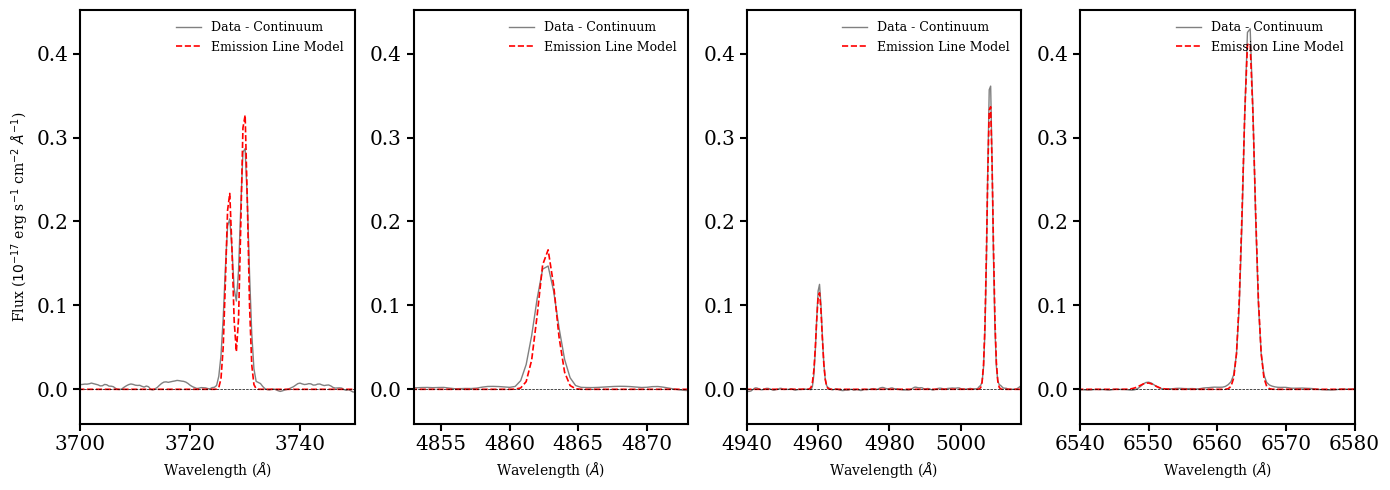

/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_noelg_8.20_8.40.fits


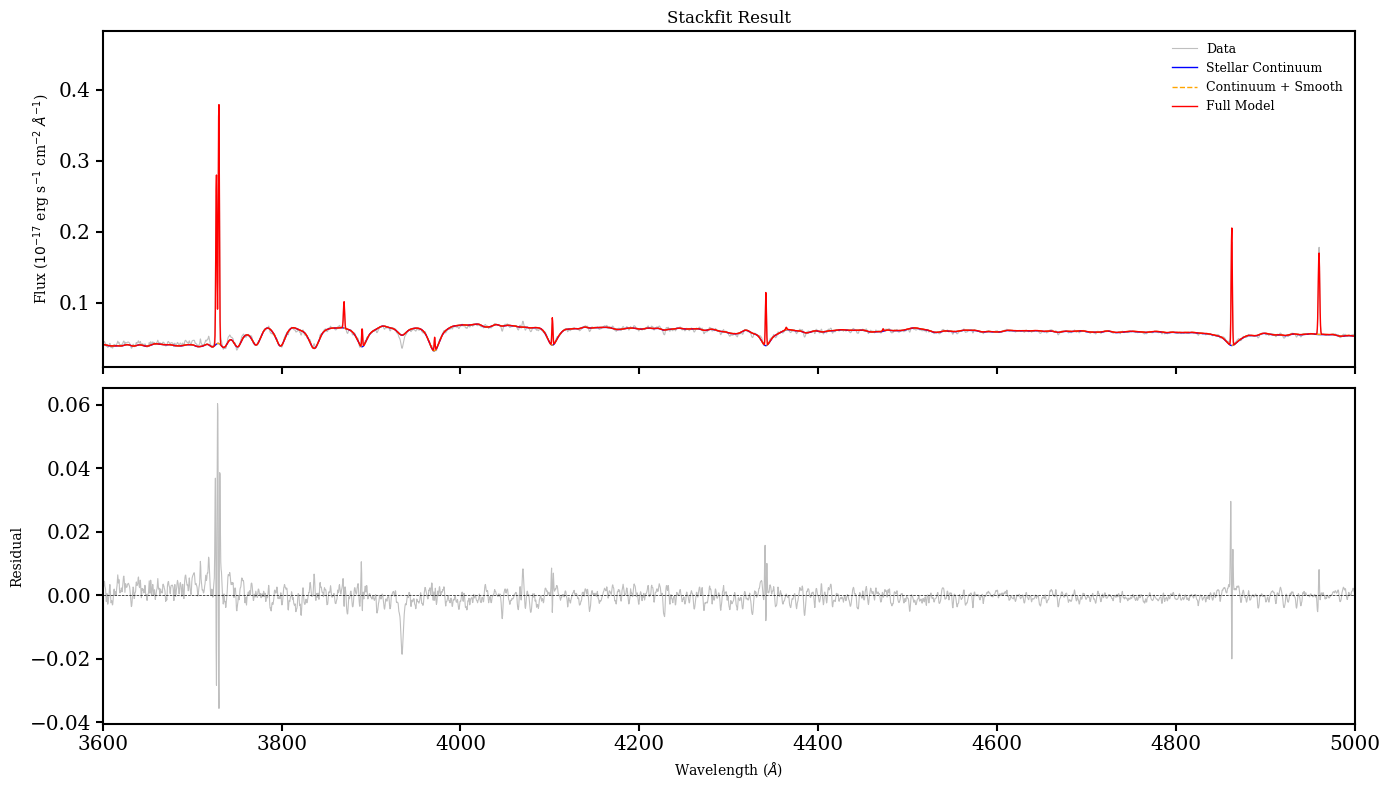

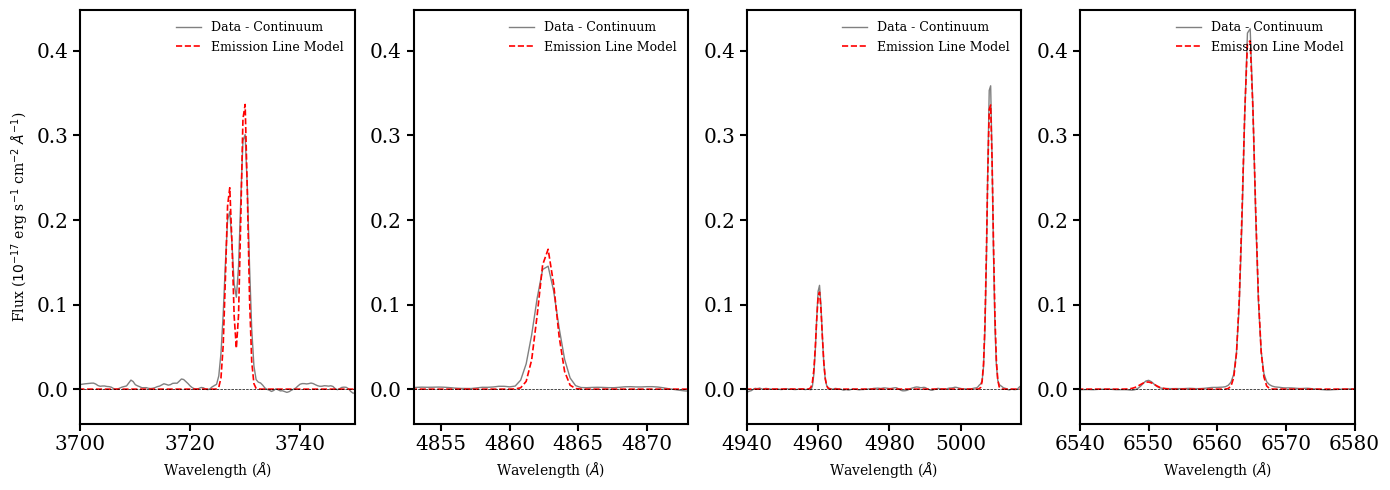

/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_noelg_8.40_8.60.fits


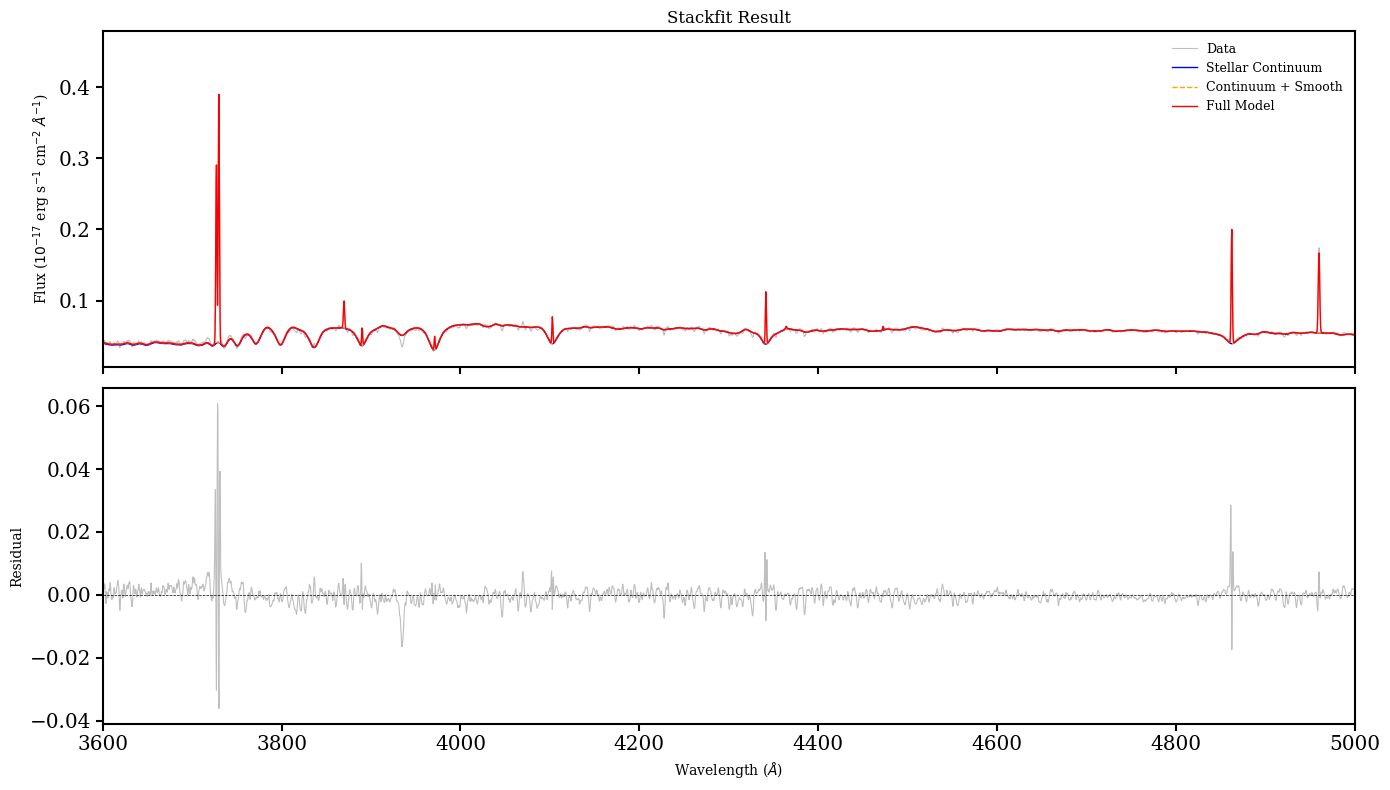

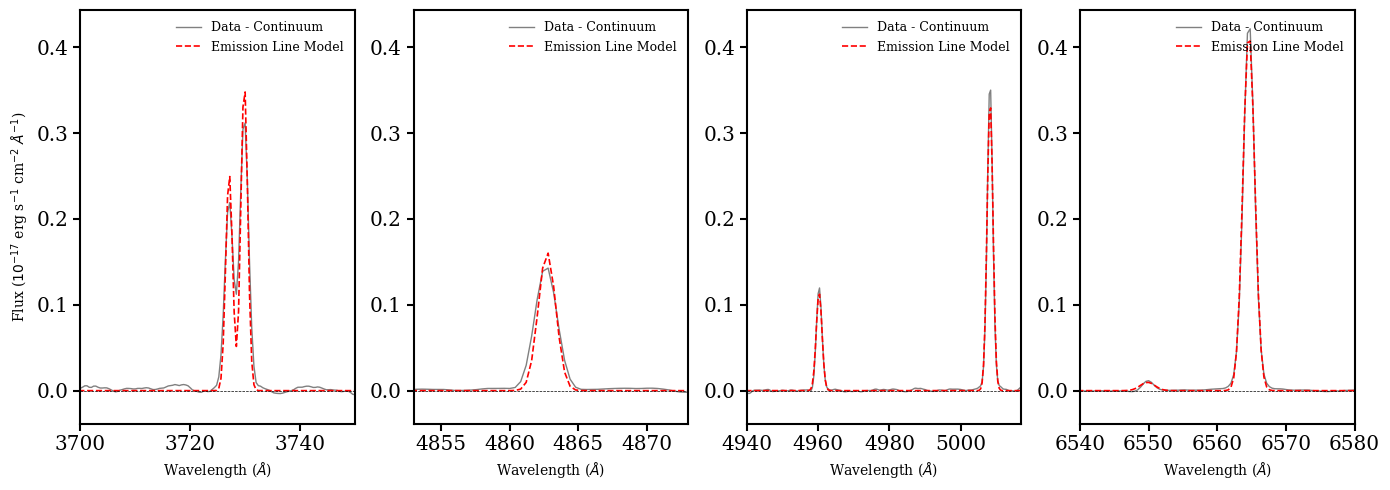

/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_noelg_8.60_8.80.fits


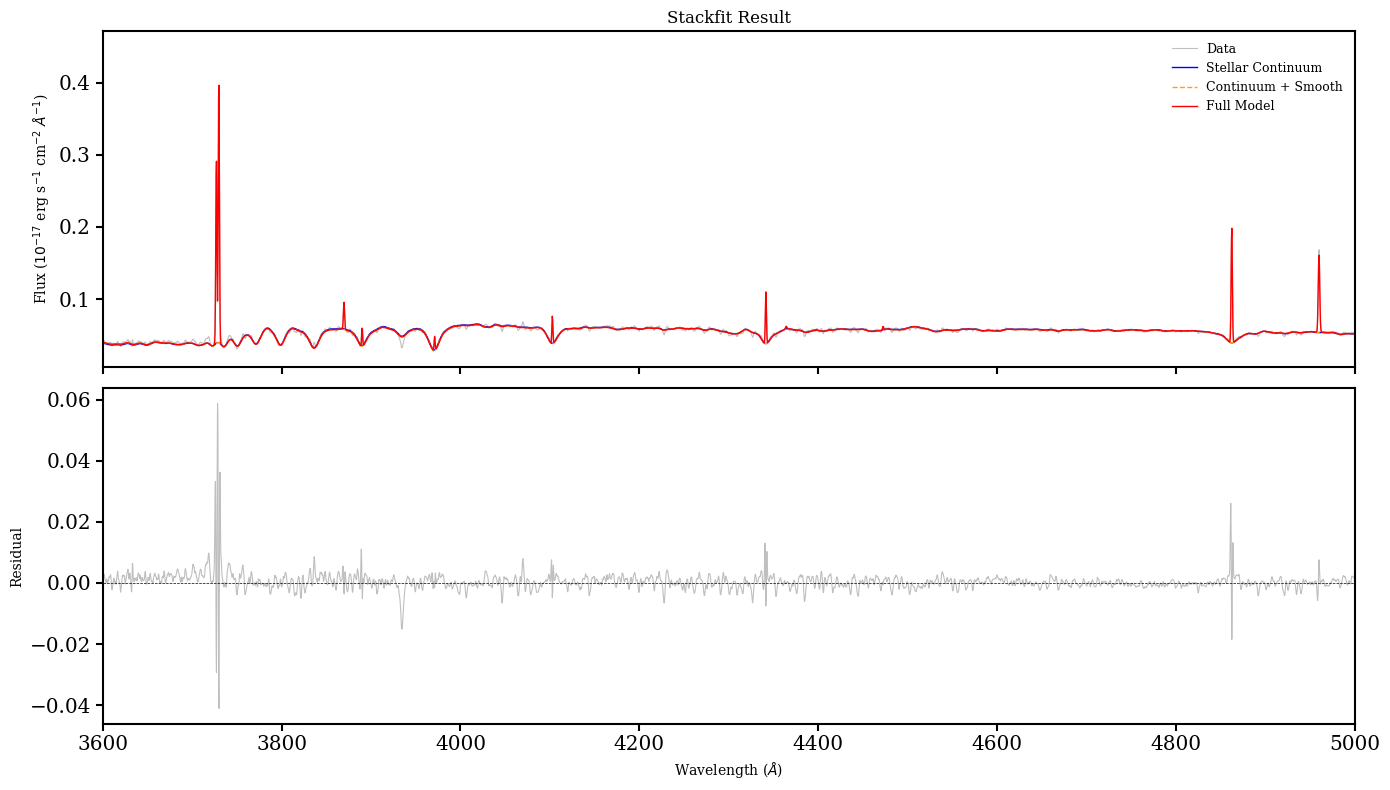

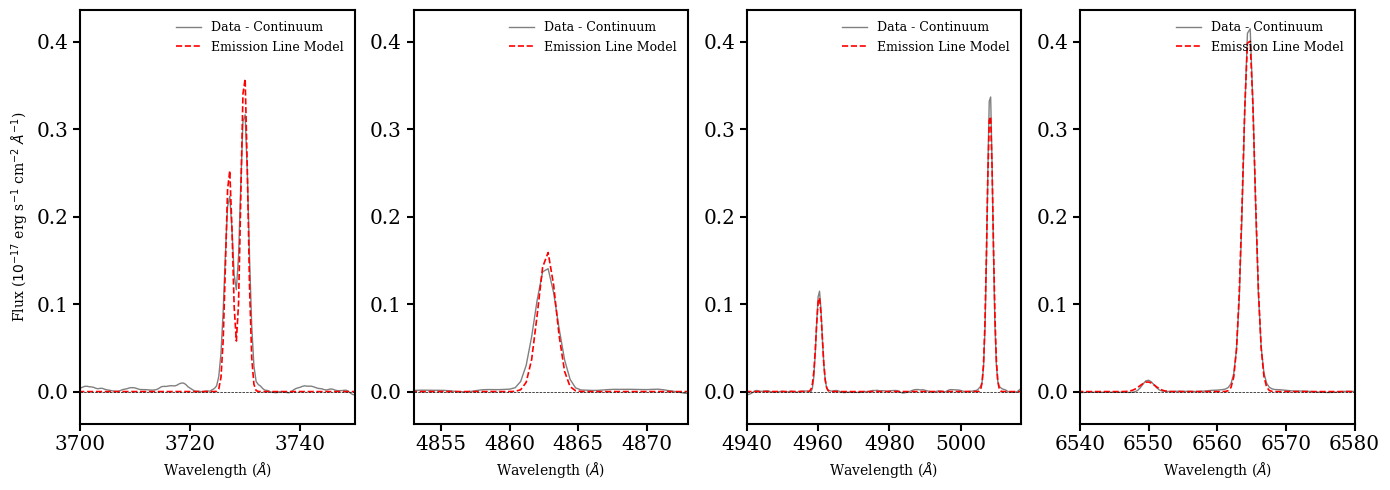

/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_noelg_8.80_9.00.fits


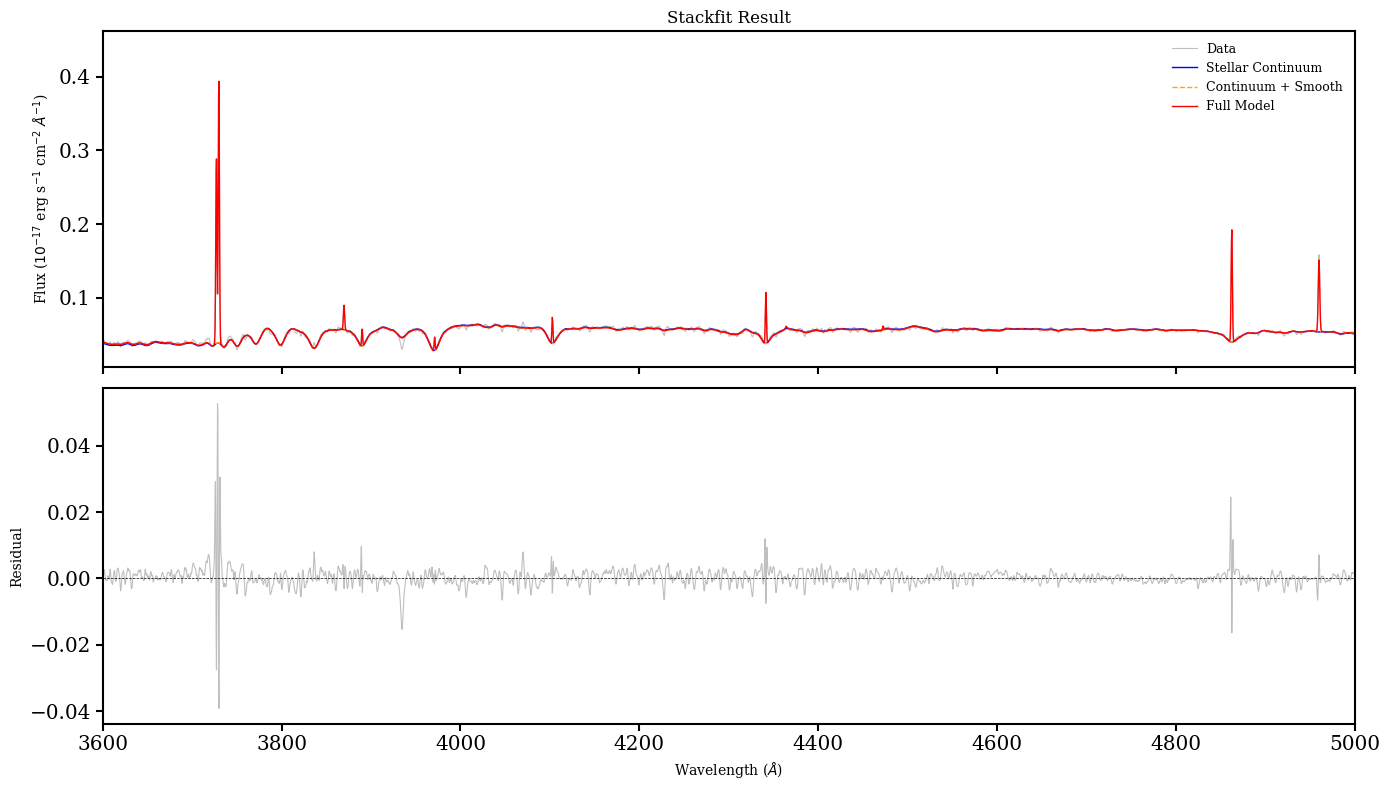

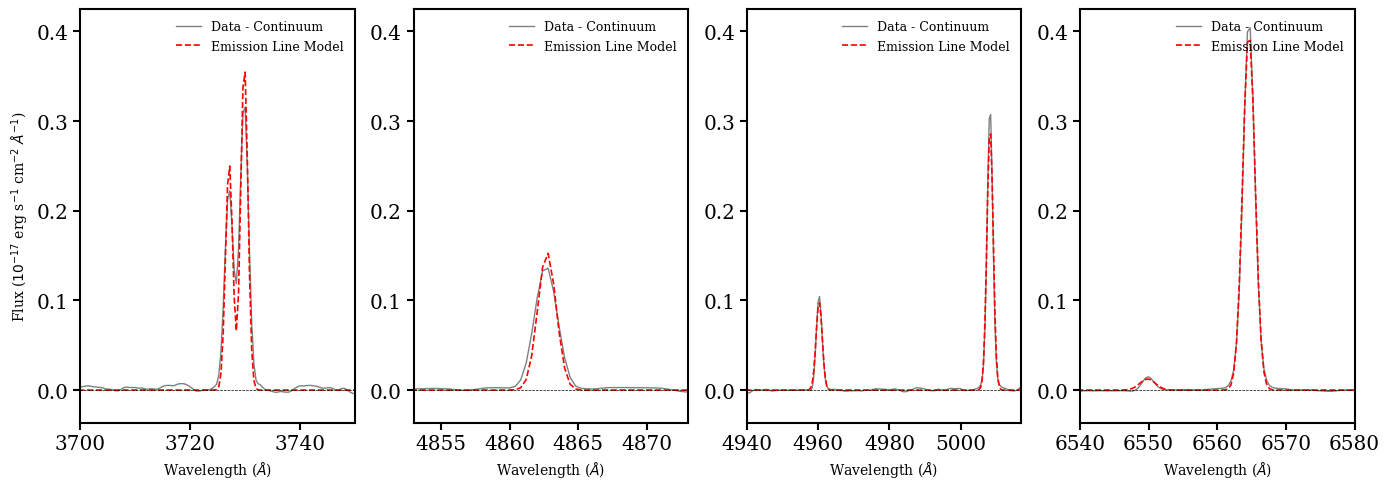

In [123]:
import numpy as np
import fitsio
import matplotlib.pyplot as plt

# ----- File paths -----
# stackfile = '/path/to/your/stacked_spectra.fits'   # input stacked spectra

for bin_idx in range(5,len(mstar_bins) - 1):

    fastfitfile = f'{stack_path}/fastspec_stack_mstar_noelg_{mstar_bins[bin_idx]:.2f}_{mstar_bins[bin_idx+1]:.2f}.fits'         # stackfit output
    print(fastfitfile)
    flux = stack_spec_noelg_mstar_dict[bin_idx]

    
    # ----- Pick which spectrum to plot (0-indexed) -----
    idx = 0
    
    # ----- Read the stacked spectrum -----
    # wave = fitsio.read(stackfile, 'WAVE')
    # flux = fitsio.read(stackfile, 'FLUX')[idx, :]
    # ivar = fitsio.read(stackfile, 'IVAR')[idx, :]
    
    
    # ----- Read the model from the stackfit output -----
    models, hdr = fitsio.read(fastfitfile, 'MODELS', header=True)
    modelwave = hdr['CRVAL1'] + np.arange(hdr['NAXIS1']) * hdr['CDELT1']
    
    # models shape: [nobj, 3, nwave]
    #   models[idx, 0, :] = stellar continuum
    #   models[idx, 1, :] = smooth (non-parametric) continuum
    #   models[idx, 2, :] = emission-line model
    continuum       = models[idx, 0, :]
    smooth_continuum = models[idx, 1, :]
    emlines         = models[idx, 2, :]
    full_model      = continuum + smooth_continuum + emlines
    
    # ----- Plot 1: Full spectrum + model -----
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    ax1.plot(wave, flux, color='gray', alpha=0.5, lw=0.8, label='Data')
    ax1.plot(modelwave, continuum, color='blue', lw=1, label='Stellar Continuum')
    ax1.plot(modelwave, continuum + smooth_continuum, color='orange', lw=1,
             ls='--', label='Continuum + Smooth')
    ax1.plot(modelwave, full_model, color='red', lw=1,ls="-", label='Full Model')
    ax1.legend(fontsize=9, loc='upper right')
    ax1.set_ylabel(r'Flux ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)')
    ax1.set_title('Stackfit Result')
    ax1.set_xlim(3600, 5000)
    
    # residual
    ax2.plot(wave, flux - np.interp(wave, modelwave, full_model),
             color='gray', alpha=0.5, lw=0.8)
    ax2.axhline(0, color='k', ls='--', lw=0.5)
    ax2.set_ylabel('Residual')
    ax2.set_xlabel(r'Wavelength ($\AA$)')
    ax2.set_xlim(3600, 5000)
    
    plt.tight_layout()
    plt.show()
    
    
    # ----- Plot 2: Zoom into emission lines (continuum-subtracted) -----
    fig, ax = plt.subplots(1,4,figsize=(14, 5))
    
    # continuum-subtracted data
    data_contsub = flux - np.interp(wave, modelwave, continuum + smooth_continuum)
    
    for axi in ax:
        axi.plot(wave, data_contsub, color='gray', alpha=1, lw=1, label='Data - Continuum')
        axi.plot(modelwave, emlines, color='red', lw=1.2, label='Emission Line Model',ls="--")
        axi.axhline(0, color='k', ls='--', lw=0.5)
        axi.legend(fontsize=9)
        ax[0].set_ylabel(r'Flux ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)')
        axi.set_xlabel(r'Wavelength ($\AA$)')
        # axi.set_title('Continuum-Subtracted Spectrum + Emission Line Model')
    
    # Uncomment to zoom into OII region:s
    ax[0].set_xlim(3700, 3750)
    
    ax[1].set_xlim(4863-10, 4863+10)
    
    ax[2].set_xlim(4950-10, 5007+10)
    
    ax[3].set_xlim(6560-20, 6560+20)
    
    
    
    
    plt.tight_layout()
    plt.show()
    
    print("==="*10)
    print("==="*10)
    print("==="*10)

